# LangChain 개요  

- 2022년 10월 말 해리슨 체이스가 제작
- LangChain은 오픈 소스로 공개되어 있어 커뮤니티에서 지속적으로 발전하고 있음
- <font color=red>LLM과 애플리케이션의 통합</font>을 간소화하도록 설계된 강력한 프레임워크
- 간단하고 통합된 API를 활용하여 개발자들이 코드를 크게 변경하지 않고 <font color=red>모델을 쉽게 교체하거나 대체</font>할 수 있도록 함
- 검색 증강 생성(RAG) 어플리케이션 제작, 구조화된 데이터 분석, 챗봇 등을 제작 가능
- 주요 기능
  - <font color=red>문맥 인식</font>: 언어 모델과 다양한 문맥 소스(프롬프트 지시, 예제, 응답의 근거 내용 등)를 연동하며, 사용자의 문맥을 정확히 이해
  - <font color=red>추론 능력</font>: 제공된 문맥에 기반하여 어떤 대답을 할지, 또는 어떠한 액션을 취할지에 대한 추론이 가능

---

- 참고
  - https://www.samsungsds.com/kr/insights/what-is-langchain.html
  - https://velog.io/@26solitude/랭체인LangChain이란
  - https://wikidocs.net/book/14473
  - https://wikidocs.net/book/14314
  - 트러블슈팅 : https://wikidocs.net/232743

# 대규모 언어 모델(Large Language Model, LLM)의 문제점
- 일반적인 상황에서 프롬프트에 응답하는 데 탁월하지만, <font color=red>훈련한 적이 없는 특정 영역에서 성능이 떨어짐</font> → hallucination(환각)
- 상태를 저장하지 않으므로 이전 <font color=red>대화 내용을 기억하지 못함</font> → 데이터베이스의 필요
- 일률적인 규칙이 없으므로 감정 분석, 분류, 질문 답변과 요약 등 <font color=red>서로 다른 시나리오에 특화된 다양한 모델을 사용</font>해야 함
- 이를 위해서 기계 학습 엔지니어가 LLM을 조직의 내부 데이터 소스와 통합하고 프롬프트 엔지니어링을 적용해야 함
- LangChain은 이러한 데이터 응답 애플리케이션을 개발하기 위한 중간 단계를 간소화하여 프롬프트 엔지니어링의 효율성을 높임
  - LLM 기반 어플리케이션을 구축하기 위해서는 프롬프트를 보내고 응답을 기다리는 것 등의 작업이 필요 (매개변수 조정, 프롬프트 보강, 응답 조정 등)


#  랭체인을 구성하는 핵심 모듈

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/langchain.png" width=40%>   
</center>  

- LLM의 가지는 다양한 문제점을 해결할 수 있는 방안을 제공

- ① <font color=red>데이터 소스</font>
  - 애플리케이션은 LLM에 대한 컨텍스트를 구축하기 위해 PDF, 웹 페이지, CSV, 관계형 데이터베이스와 같은 외부 소스에서 데이터를 검색해야 함
  - 랭체인은 서로 다른 소스에서 데이터에 액세스하고 검색할 수 있는 모듈과 원활하게 통합

- ② <font color=red>단어 임베딩(벡터 임베딩)</font>
  - 일부 외부 소스에서 검색한 데이터는 벡터로 변환해야 함
  - 선택한 LLM을 기반으로 최적의 임베딩 모델을 선택

- ③ <font color=red>벡터 데이터베이스</font>
  - 메모리 내 배열부터 파인콘(Pinecone)과 같은 호스팅 벡터 데이터베이스에 이르기까지 다양한 소스에서 벡터를 쉽게 저장하고 검색할 수 있도록 지원

- ④ <font color=red>언어 모델(LLM)</font>
  - 랭체인은 오픈AI, 코히어(Cohere), AI21에서 제공하는 주류 LLM과 허깅페이스(Hugging Face)에서 제공되는 오픈소스 LLM을 지원, 추가되는 LLM도 빠르게 업데이트
.

### LangChain 프레임워크 및 모듈의 작동 방식
<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/langchain2.png" width=60%>   
</center>

- <font color=red>에이전트</font>
  - LangChain에서 LLM(대형 언어 모델)을 사용하여 여러 작업(예: 데이터 검색, 계산, 번역 등)을 순서대로 또는 동적으로 선택하고 실행하는 모듈 `(일종의 동적 체인)`
  - ReAct 프롬프트 기법을 단순화하여 추론과 행동을 가능하게 함
  > ReAct??
  > - Reasoning and Acting 의 줄인 말
  > - 언어모델이 추론과 행동을 동시에 수행하도록 도와주는 방법
  > - 전통적인 방식은 단순히 답변만 내놓았다면, ReAct는 "이 문제를 어떻게 해결할지 고민(추론)하고, 그에 맞게 행동(ex.API 호출, 데이터 검색 등)을 실행하는 방식
  
    > ReAct 예시
    > - 에이전트의 역할
    >    - 추론: “내가 가지고 있는 재료는 무엇일까? 그리고 추가로 필요한 재료는 무엇일까?”
    >    - 행동: “주변 마트에서 재료를 주문하자” 또는 “냉장고에 있는 재료로 만들 수 있는 요리를 추천하자.”
    >
    > - ReAct 적용:
    > - 언어 모델이 “냉장고에 있는 재료”라는 정보를 바탕으로 “어떤 요리를 할 수 있을까?”를 고민(추론)한 후,
    > - 실제로 “요리법 검색”이나 “재료 구매”라는 행동을 실행

- <font color=red>Memory</font>
  - LLM은 상태를 저장하지 않지만 정확한 응답을 위해서는 컨텍스트가 필요
  - 단기 및 장기 메모리를 쉽게 추가할 수 있도록 지원
    - 단기 메모리는 간단한 메커니즘을 통해 대화 기록을 저장하고 관리
    - 메시지 기록은 레디스(Redis) 같은 외부 소스에 저장돼 장기 메모리를
유지할 수 있음

- <font color=red>콜백</font>
  - 특정 시점(ex.이벤트)에서 호출하여 사용하는 함수 구조
  - 개발자에게 LLM 애플리케이션의 다양한 단계에 연결할 수 있는 콜백 시스템을 제공하며 로깅, 모니터링, 스트리밍 및 기타 작업에 유용

- <font color=red>데이터 연결</font>
  - RAG에 초점을 맞춰 생성 단계에서 필요한 데이터를 외부 데이터 소스에서 가져오는 작업을 담당
  - 외부 문서를 로드하고, 일괄적으로 단어 임베딩으로 변환한 다음, 임베딩을 벡터 데이터베이스에 저장하고, 마지막으로 쿼리를 통해 검색

- <font color=red>체인</font>
  - 구성 요소와 LLM을 활용하여 예상되는 응답을 얻는 효율적인 파이프라인을 구축하도록 설계
  - 예를 들어, 체인은 문서를 요약한 다음 이에 대한 감정 분석을 수행하는 프롬프트가 포함될 수 있음

- <font color=red>모델 I/O</font>
  - LLM과의 상호 작용을 처리
  - 프롬프트 관리, 최적화 및 LLM과의 일반적인 인터페이스와 작업을 위한 유틸리티를 포함




### LangChain의 동작

#### 모델 I/O : 언어 모델과의 인터페이스
- 프롬프트를 관리하고 공통 인터페이스를 통해 언어 모델을 호출하고 모델 출력에서 정보를 추출

<center>  
Model I/O 개념도<br>
<img src="https://arome1004.cafe24.com/images/deeplearning/langchain3.png" width=80%> <br>
</center>

> 1. **Format 단계**  
   - 입력 데이터(예: `x = "foo"`, `y = "bar"`)를 활용하여 최종적으로 LLM에 전달할 **프롬프트**(질문, 명령 등)를 형성함
   - 예시로, “`Does foo like bar, and why?`”라는 문장을 생성하여 LLM에게 전달할 형태로 가공하는 모습이 보임

> 2. **Predict 단계**  
   - **LLM** 혹은 **Chat Model**이 “Format 단계”에서 생성된 프롬프트를 입력받아 예측(추론) 과정을 수행함  
   - 예시에서 LLM이 출력한 내용은 “`Foo does…`”와 같은 텍스트 응답임

> 3. **Parse 단계**  
   - LLM이 생성한 텍스트 응답을 후처리하여, **JSON**과 같은 특정 형식으로 **구문 분석(Parsing)** 함  
   - 예시로, “`{ "likes": true, "reason": "Because..." }`”처럼 결과를 구조화된 데이터 형태로 변환하여 다른 시스템이 쉽게 처리하거나 후속 작업에 활용할 수 있도록 함

---

#### 데이터 연결 : 애플리케이션별 데이터와의 인터페이스
- 데이터 로드, 변환, 저장 및 쿼리하기 위한 빌딩 블록을 제공
- LangChain은 **데이터 소스 → 로딩 → 변환 → 임베딩 → 저장 → 검색**의 일련 과정을 모듈화하여, 개발자가 대규모 언어 모델과 외부 데이터를 손쉽게 연결하고 활용할 수 있도록 도움

<center>
Data Connection 흐름도 <br>
<img src="https://arome1004.cafe24.com/images/deeplearning/langchain4.png" width=80%>   
</center>

> 1. **Source (데이터 소스)**  
   - 텍스트, 이미지, PDF, 소셜 미디어, 웹사이트 등 다양한 외부 데이터가 존재함
   - 애플리케이션에서 활용하고자 하는 **모든 데이터가 출발하는 지점**

> 2. **Load (로딩)**  
   - 데이터 소스에 있는 원시(raw) 데이터를 LangChain 애플리케이션으로 가져오는 단계  
   - PDF 파일에서 텍스트를 추출하거나, 웹 API에서 정보를 받아오는 등, **데이터를 애플리케이션이 처리 가능한 형태**로 로드함

> 3. **Transform (변환)**  
   - 로드된 데이터를 필요한 형태로 가공하거나 전처리하는 과정  
   - 예: 텍스트를 문장 단위로 분할, 불필요한 공백 제거, 언어 감지 등.

> 4. **Embed (임베딩)**  
   - 전처리된 텍스트나 문서 등을 **벡터(수치) 형태로 변환**하는 과정  
   - LLM이나 임베딩 모델을 통해 텍스트를 벡터로 변환하여 **유사도 검색** 등에 활용할 수 있음

> 5. **Store (저장)**  
   - 임베딩된 벡터를 벡터 데이터베이스나 다른 스토리지 시스템에 저장하는 단계  
   - 예: Pinecone, Redis, FAISS 등 다양한 벡터 데이터베이스를 사용함

> 6. **Retrieve (검색/검색 결과 활용)**  
   - 저장된 벡터를 토대로, 유사도 검색 등을 통해 **원하는 데이터를 빠르고 정확하게 조회**하는 단계  
   - 검색된 결과는 다시 LLM에 전달하거나, 후속 작업(예: 요약, 질의응답 등)에 사용됨

---

#### 메모리
- 대화형 시스템에 필요한 어느 정도 기간의 과거 메시지에 직접 액세스 기능 지원
- **Memory**는 대화의 **맥락(과거 대화 기록)**을 보존하고, 이를 모델에게 제공해 **연속적인 질의응답**이 가능하게 함  
- **READ**와 **WRITE** 과정을 통해 모델이 대화 중에 점진적으로 축적된 정보를 계속 참고할 수 있음
- `체인` 실행 간 애플리케이션 상태 유지
> `체인`??
  - 랭체인은 체인으로 연결된 애플리케이션을 위한 체인 인터페이스를 제공
  - LangChain에 다양한 AI 구성 요소를 유지하며 컨텍스트 인식 응답을 제공한다는 기본 원칙
  - 사용자의 쿼리부터 모델의 출력에 이르기까지 일련의 자동화된 작업

<center>
메모리 모듈 개념도 <br>
<img src="https://arome1004.cafe24.com/images/deeplearning/langchain5.png" width=80%>   
</center>

> 1. **과거 메시지(“past_messages”)**  
   - 이전에 주고받았던 질문과 답변 등, **대화의 맥락**이 담겨 있음
   - LangChain은 이 과거 대화 기록을 **Memory**에 저장해두고 필요할 때 불러옴

> 2. **READ 단계**  
   - 모델이 새 질문(“question”)을 처리하기 전에, **Memory**로부터 과거 메시지(맥락)를 읽어와서 **프롬프트**를 구성함  
   - 예: “(past_messages) (question)” 형태로 과거 대화와 새 질문을 합쳐 모델에 전달

> 3. **Model 추론**  
   - 모델(LLM)은 주어진 프롬프트(과거 메시지 + 현재 질문)에 대해 **응답**을 생성함  
   - 이때, **출력 파서(Output parser)**를 사용해 모델 응답을 특정 형식(예: JSON, 정규표현식 등)으로 변환할 수도 있음

> 4. **WRITE 단계**  
   - 모델이 생성한 응답(“answer”)을 **Memory**에 다시 저장하여, 이후 대화에서 **맥락**으로 활용할 수 있도록 함  
   - 이렇게 메모리에 쓰여진 정보는 다음 질문 시에 다시 **READ** 단계를 거쳐 모델에 제공됨






# LangChain 라이브러리
- LangChain Python 기반 공식 가이드 문서 : https://python.langchain.com/docs/introduction/

| 항목                                               | 내용                                                                                                                                                                                                                                                                              |
| :------------------------------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| <font color=red>LangChain</font>                  | 기본 런타임 및 즉시 사용 가능한 체인(Chain)과 에이전트(Agent)의 구현을 포함하여 **LLM 기반 애플리케이션**을 쉽게 구성할 수 있는 핵심 라이브러리<br>주요 모듈(체인, 에이전트, 메모리, 데이터 연결 등)을 제공하며 **프롬프트 엔지니어링**을 체계화할 수 있음<br>                         |
| <font color=red>LangChain Template</font>         | 다양한 작업에 대한 **참조 아키텍처** 또는 템플릿을 제공하여 쉽게 배포 가능<br>실제로는 **LangChain Hub**나 **PromptTemplate**와 같은 형태로 존재하며, 특정 사용 사례별 예시를 공유하기도 함<br>따라서 'LangChain Template'라는 별도의 라이브러리는 아니며 **샘플/템플릿 모음**에 가까움<br> |
| <font color=red>LangServe</font>                  | LangChain 체인을 **REST API**로 배포하기 위한 라이브러리<br>체인(Chain)을 **마이크로서비스** 형태로 제공하여 서버 환경에서 체인 실행을 관리하고, 외부 HTTP 요청에 대한 응답을 쉽게 제공할 수 있음<br>                                                                                 |
| <font color=red>LangSmith</font>                  | LangChain으로 구축된 체인을 **디버그, 테스트, 평가, 모니터링**할 수 있도록 해주는 개발자 플랫폼<br>LangChain과 원활하게 통합되어, 프로토타입에서 프로덕션으로 이전할 때 **언어 모델 애플리케이션** 및 **지능형 에이전트**를 추적하고 평가하는 데 유용<br>모델 응답의 품질 측정, 체인 성능 분석, 버전 관리 등을 제공하여 **운영 환경에서의 안정성** 확보에 도움<br> |
| <font color=red>LangGraph</font>                  | LLM을 사용해 상태 유지를 지원하는 **다중 액터(Multi-actor) 애플리케이션**을 구축하기 위한 라이브러리<br>LangChain의 에이전트·메모리 등과 함께 사용하여 **대규모 멀티스텝 워크플로**를 설계할 수 있음<br>                                                                               |

---

## LangChain의 장점

| 분류                | 주요 내용                                                                                                                                                                          |
| :------------------ | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 언어 모델 용도 변경 | **재훈련이나 미세 조정 없이** LLM을 다양한 분야의 애플리케이션에 재활용 가능<br>독점 정보를 참조해 모델 응답을 보강하는 **복잡한 애플리케이션** 구축 가능<br>**RAG**(검색 증강 생성) 워크플로를 통해 모델 할루시네이션(거짓 정보 생성)을 줄이고 **응답 정확도** 향상<br> |
| AI 개발 간소화      | 복잡한 데이터 소스 통합과 **프롬프트 세분화** 과정을 추상화하여 AI 개발을 간소화<br>개발자는 **시퀀스**를 사용자 지정해 복잡한 애플리케이션을 빠르게 구축 가능<br>                                                         |
| 개발자 지원         | 언어 모델을 **외부 데이터 소스**와 연결하기 위한 다양한 도구 제공<br>오픈 소스이자 활발한 커뮤니티 지원으로 **지속적 업데이트** 및 풍부한 예시 확보<br>                                                                     |



# LangChain 설치


- 의존성 라이브러리 설치

In [1]:
!pip install -qU openai langchain-openai langchain langchain_community

!pip install -qU tiktoken pypdf chromadb faiss-cpu

!pip install -qU langchain-teddynote

!pip install -qU huggingface_hub langchain_huggingface
 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

# API key 획득 및 설정



- OpenAI 로그인 및 결재 등록
  - https://platform.openai.com/docs/overview 에 접속
  - Sign Up을 클릭하여 로그인
  - 우측 상단의 Setting 버튼(⚙️)을 클릭
  - Billing 메뉴에서 Add pyayment details 버튼을 클릭하여 신용카드를 등록

  <center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/openai_reg01.png" width=60%>   
</center>

    - "Add to credit balance" 버튼을 눌러 사용할만큼의 미화(달러)를 입력
      - 금액은 $5 부터 추가가 가능 (최소금액)
    - 금액을 입력한 후 "Continue" 를 눌러 결제를 진행  
      - 왼쪽의 "Limits" 탭에서 월간 사용한도를 설정

  - 신용카드를 등록했다면 등록된 신용카드는 Payment methods 탭을 클릭하면 확인 가능






### OpenAI API 키 발급 및 테스트
- 우측 프로필 이미지 클릭 → `Your profile` 클릭
- `User API keys` 클릭 → `Create new secrete key` 버튼을 클릭
- 이름 입력
- API 키 복사
> ⚠️주의사항 : API 키는 한번만 제공됨, 복사하여 개인 메모장(또는 마크다운)에 저장해둘 것을 권장

  <center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/openai_key.png" width=40%>   
</center>

  <center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/openai_key02.png" width=40%>   
</center>

  <center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/openai_key03.png" width=40%>   
</center>

- API 키 등록

In [ ]:
# OpenAI API 키 설정
import os

# API 키를 환경 변수로 설정 (실제 사용 시 자신의 키로 교체)
os.environ["OPENAI_API_KEY"] = "sk-f_Ae5L9K9tiyYUCTa8_wJuF5c194uBcz2IofaZNBxwT3BlbkFJqTsPggjlugRL-et4nfI_ci3QeYCo3NGiuGF1RPNcEA"

# LangChain에서 OpenAI 모델 사용을 위한 설정 확인
print("OpenAI API Key 설정 완료")
print(f"API Key: {os.environ['OPENAI_API_KEY'][:20]}...")  # 보안을 위해 일부만 표시

# 프롬프트 작성 원칙
- 모델이 최대한 정확하고 유용한 정보를 제공할 수 있도록 효과적인 프롬프트를 작성하는 것이 매우 중요

- 명확성과 구체성
  - 질문은 명확하고 구체적이어야 함 (모호한 질문은 LLM 모델의 혼란을 초래)
  - 예시:  "주식 시장은 ?" -> "다음 주 주식 시장에 영향을 줄 수 있는 예정된 이벤트들은 무엇일까?"

- 배경 정보 포함
  - 모델이 문맥을 이해할 수 있도록 필요한 배경 정보 제공 (환각 현상(hallucination) 감소 및 관련성 높은 응답 생성)
  - 예시: "2020년 미국 대선의 결과를 바탕으로 현재 정치 상황에 대한 분석을 해주세요"
  
- 간결함
  - 핵심 정보에 초점을 맞추고, 불필요한 정보는 배제 (복잡하면 덜 중요한 부분에 집중하거나 상당한 영향을 받는 문제 발생)
  - 예시: "2021년에 발표된 삼성전자의 ESG 보고서를 요약해주세요."

- 열린 질문 사용
  - 열린 질문을 통해 모델이 자세하고 풍부한 답변을 제공하도록 유도 (예/아니오로 답변하는 질문보다는 많은 답변을 요구하는 질문)
  - 예시: "신재생에너지에 대한 최신 연구 동향은 무엇인가요?"

- 명확한 목표 설정
  - 얻고자 하는 정보나 결과의 유형을 정확하게 정의 (명확한 지침에 따라 응답을 생성)
  - 예시: "AI 윤리에 대한 문제점과 해결 방안을 요약하여 설명해주세요."

- 언어와 문체
  - 대화의 맥락에 적합한 언어와 문체를 선택 (상황에 맞는 표현 선택)
  - 예시: 공식적인 보고서를 요청하는 경우, "XX 보고서에 대한 전문적인 요약을 부탁드립니다."와 같이 정중한 문체를 사용


# GPT?

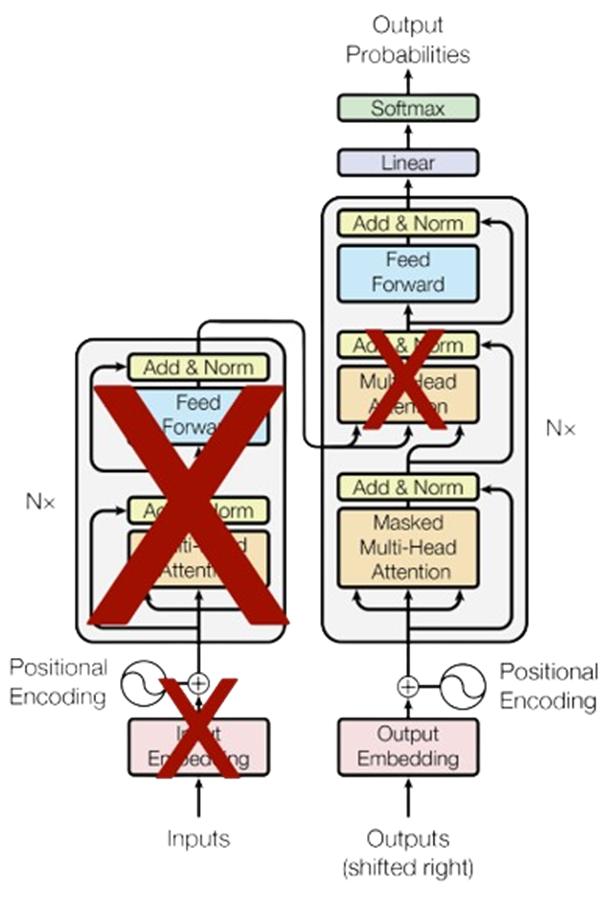

- GPT (Generative Pre-trained Transformer) : 대규모 텍스트 데이터를 학습한 후, 주어진 텍스트 입력에 대한 예측과 텍스트 생성을 수행하는 모델.

- 트랜스포머의 디코더 구조 사용 : GPT는 트랜스포머의 디코더 구조만을 사용함
  - 디코더는 새로운 문장을 생성하는 역할을 맡음
  - 디코더는 앞에 나온 단어들을 참고하여 다음 단어를 예측해 문장을 만들어냄

- 일방향 모델 : 문장을 왼쪽에서 오른쪽으로 한 방향으로만 이해함
  - 이는 단어를 순차적으로 생성하는 데에 강점을 줌
  - 예를 들어, GPT는 “I love reading”이라는 문장이 주어졌을 때, 다음에 나올 단어를 예측하는 데 매우 뛰어난 성능을 보임

- 문장 생성에 강점 : GPT는 주어진 문맥을 바탕으로 새로운 문장을 생성하는 데에 매우 능숙함
  - 대화형 AI, 자동 글쓰기, 스토리 생성 등 문장을 만들어내는 작업에서 강력한 성능을 보임

---

- 추가 보완 사항:
  - BERT는 양방향 특성으로 인해 문장을 더 잘 이해할 수 있지만, 생성 작업에는 적합하지 않다는 점
  - GPT는 일방향 모델로서 문장의 생성에는 뛰어나지만, 문장의 전체적인 의미를 이해하는 데는 BERT만큼 강하지 않다는 점


# GPT 모델 기본 구조
- Self-Attention Mechanism: 문장 내의 단어들이 서로 어떤 관계를 맺고 있는지를 파악하는 메커니즘.
- Position-wise Feed-Forward Networks: 각 단어의 위치 정보를 고려하여 처리를 진행.
- Multi-Head Attention: 다양한 관점에서 단어 간의 관계를 살펴보는 방법.

### Huggingface 모델로 맛보기

In [ ]:
# Huggingface 모델 기본 사용 예제
from langchain_huggingface import HuggingFacePipeline
from transformers import pipeline

# Huggingface 파이프라인 생성 (한국어 텍스트 생성 모델)
# 작은 크기의 한국어 모델 사용 (실제 사용 시 더 큰 모델로 교체 가능)
hf_pipeline = pipeline(
    "text-generation",
    model="skt/kogpt2-base-v2",  # 한국어 GPT-2 모델
    max_new_tokens=50,
    temperature=0.7,
    do_sample=True,
    pad_token_id=2  # EOS 토큰
)

# LangChain HuggingFacePipeline 래퍼 생성
hf_model = HuggingFacePipeline(pipeline=hf_pipeline)

# 간단한 텍스트 생성 테스트
prompt = "한국의 수도는"
result = hf_model.invoke(prompt)
print("입력:", prompt)
print("출력:", result)

In [ ]:
# 다른 Huggingface 모델 예제 (영어 모델)
from langchain_huggingface import HuggingFacePipeline
from transformers import pipeline

# 영어 텍스트 생성을 위한 GPT-2 모델
english_pipeline = pipeline(
    "text-generation",
    model="gpt2",  # 기본 GPT-2 모델
    max_new_tokens=30,
    temperature=0.8,
    do_sample=True
)

# LangChain 래퍼 생성
english_model = HuggingFacePipeline(pipeline=english_pipeline)

# 영어 텍스트 생성 테스트
english_prompt = "The future of AI is"
english_result = english_model.invoke(english_prompt)
print("영어 입력:", english_prompt)
print("영어 출력:", english_result)

In [ ]:
# Huggingface 모델 비교 예제
import pandas as pd

# 두 모델의 성능 비교를 위한 테스트
test_prompts = [
    "인공지능의 발전은",
    "The development of AI",
    "머신러닝이란",
    "Machine learning is"
]

results = []
for prompt in test_prompts:
    try:
        # 한국어 모델 테스트
        ko_result = hf_model.invoke(prompt)
        # 영어 모델 테스트
        en_result = english_model.invoke(prompt)

        results.append({
            'prompt': prompt,
            'korean_model': ko_result[:100] + "..." if len(ko_result) > 100 else ko_result,
            'english_model': en_result[:100] + "..." if len(en_result) > 100 else en_result
        })
    except Exception as e:
        print(f"Error with prompt '{prompt}': {e}")

# 결과 비교 테이블 출력
df_comparison = pd.DataFrame(results)
print("모델 비교 결과:")
print(df_comparison.to_string(index=False))

- GPT 버전별 특징

| GPT 버전    | 출시년도 | 주요 특징 및 개선점                                                                                                                                                                                                                                                                                                            | 모델 규모 (파라미터)                                        |
|-------------|----------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------|
| **GPT-1**   | 2018     | - Transformer 구조를 기반으로 최초의 GPT 모델<br>- 자연어 생성 및 이해의 가능성을 실험적으로 입증함                                                                                                                                                                                                                             | 약 **117M**                                               |
| **GPT-2**   | 2019     | - 모델 규모와 성능이 크게 향상됨<br>- 뛰어난 텍스트 생성 능력으로 주목받음<br>- 남용 위험 문제로 초기에는 전체 공개가 지연됨                                                                                                                                                                                                    | 약 **1.5B**                                               |
| **GPT-3**   | 2020     | - Few-shot 학습 등 다양한 작업 수행 능력 극대화<br>- 자연어 처리의 다재다능함을 입증<br>- 상업적 활용 및 연구에 폭넓게 응용됨                                                                                                                                                                                                 | 약 **175B**                                               |
| **GPT-3.5** | 2022     | - 대화형 응용(예: ChatGPT)과 코드 생성 성능 개선<br>- 사용자 피드백 반영 미세 조정(Fine-tuning)을 통해 성능 향상<br>- GPT-3 대비 더 자연스러운 대화와 응답 제공                                                                                                                                                              | 공식 수치는 공개되지 않았으나 GPT-3 대비 확장된 규모로 추정됨   |
| **GPT-4**   | 2023     | - 멀티모달 입력(텍스트, 이미지 등) 지원<br>- 향상된 추론 능력 및 정밀도, 안전성 강화<br>- 다양한 응용 분야에서의 활용성이 극대화됨                                                                                                                                                                                                | 공식 수치는 공개되지 않았으나 GPT-3보다 크게 확장된 규모로 추정됨 |
| **GPT-5**   | 향후 출시 (예상) | - **미래 전망**: 더욱 정교한 언어 이해 및 생성, 멀티모달 입력의 확장, 안전성 및 효율성 강화<br>- 계산 최적화 및 더 효과적인 학습 기법 적용으로, 다양한 응용 분야에서 혁신적인 성능 제공 기대<br>- 연구 및 산업 전반에 걸쳐 **새로운 가능성** 제시 예상                                                            | 예상: **수천억 ~ 수조 단위** (추정치, 공식 발표 전까지는 불확실함)     |


# LangChain 모델 유형
- <font color=red>LLM</font>과 <font color=red>Chat Model</font> 클래스을 지원
- LLM은 주로 <font color=red>단일 요청에 대한 출력을 생성</font>하는 반면, Chat Model은 <font color=red>사용자와의 상호작용을 통한 연속적인 대화 관리</font>에 더 적합
- 공식 가이드에서는 LLM보다는 `Chat Model`을 권장

# LLM 클래스
- 기능: <font color=red>텍스트 문자열을 입력으로 받아 처리한 후, 텍스트 문자열을 반환</font>
- 광범위한 언어 이해 및 텍스트 생성 작업에 사용

> LLM 모델 가이드 : https://python.langchain.com/docs/integrations/llms/
> - 다양한 LLM 모델을 LangChaine에서 어떻게 다룰 수 있는지에 대한 각각의 가이드라인 명세

- LLM 클래스 사용해보기

In [ ]:
# LLM 클래스 기본 사용 예제
from langchain_openai import OpenAI

# OpenAI LLM 모델 초기화
llm = OpenAI(
    model_name="gpt-3.5-turbo-instruct",  # 텍스트 전용 모델
    temperature=0.7,  # 창의성 조절 (0-1)
    max_tokens=100    # 최대 토큰 수
)

# 간단한 텍스트 생성
prompt = "인공지능의 장점 3가지를 설명해주세요."
response = llm.invoke(prompt)

print("프롬프트:", prompt)
print("응답:", response)

In [ ]:
# LLM 클래스 - 다양한 temperature 설정 비교
from langchain_openai import OpenAI

# 같은 프롬프트에 대해 다른 temperature로 테스트
prompt = "미래의 교통수단에 대해 상상해서 설명해주세요."

temperatures = [0.1, 0.7, 1.0]  # 낮음, 중간, 높음
responses = {}

for temp in temperatures:
    llm_temp = OpenAI(
        model_name="gpt-3.5-turbo-instruct",
        temperature=temp,
        max_tokens=150
    )

    response = llm_temp.invoke(prompt)
    responses[f"temp_{temp}"] = response

    print(f"\n=== Temperature: {temp} ===")
    print(response)

> 템플릿 활용 맛보기 (체인 사용 없이 구현)
- Python 문자열 포맷팅 비슷
- 프롬프트를 구조화(ex.자주쓰는 프롬프트)하여 활용 가능

In [ ]:
# 기본 문자열 템플릿 예제 (PromptTemplate 클래스 사용하지 않음)
from langchain_openai import OpenAI

# Python 문자열 포맷팅을 사용한 템플릿
template = "안녕하세요, {name}님! 당신의 관심사는 {interest}인가요? 이에 대해 {question} 알려주세요."

# 변수 값 설정
variables = {
    "name": "철수",
    "interest": "인공지능",
    "question": "어떻게 공부하면 좋을지"
}

# 템플릿에 변수 적용
prompt = template.format(**variables)

print("템플릿:", template)
print("변수:", variables)
print("최종 프롬프트:", prompt)

# LLM으로 실행
llm = OpenAI(model_name="gpt-3.5-turbo-instruct", temperature=0.7, max_tokens=100)
response = llm.invoke(prompt)
print("\nLLM 응답:", response)

In [ ]:
# 여러 변수를 사용한 템플릿 예제
from langchain_openai import OpenAI

# 더 복잡한 템플릿
complex_template = """
제품: {product}
카테고리: {category}
가격: {price}원
특징: {features}

위 제품에 대한 리뷰를 작성해주세요. 다음 측면을 고려해서 작성하세요:
- 장점: {pros}
- 단점: {cons}
- 추천 대상: {target_audience}
"""

# 변수 설정
product_vars = {
    "product": "갤럭시 S24 울트라",
    "category": "스마트폰",
    "price": "1,500,000",
    "features": "200MP 카메라, S펜 지원, 긴 배터리 수명",
    "pros": "고화질 카메라, 강력한 성능",
    "cons": "높은 가격",
    "target_audience": "사진 촬영을 즐기는 전문가"
}

# 템플릿 적용
final_prompt = complex_template.format(**product_vars)

print("최종 프롬프트:")
print(final_prompt)

# LLM 실행
llm = OpenAI(model_name="gpt-3.5-turbo-instruct", temperature=0.8, max_tokens=200)
review = llm.invoke(final_prompt)
print("\n생성된 리뷰:")
print(review)

In [ ]:
# 조건부 로직이 포함된 템플릿 예제
from langchain_openai import OpenAI

def create_review_template(product_type, is_positive=True):
    """제품 타입에 따른 리뷰 템플릿 생성"""
    base_template = """
제품명: {product_name}
제품 타입: {product_type}

{conditional_part}

요청사항: 위 정보를 바탕으로 {review_type} 리뷰를 작성해주세요.
"""

    if product_type == "전자제품":
        conditional_part = "배터리 수명: {battery_life}\n카메라 화질: {camera_quality}"
    elif product_type == "의류":
        conditional_part = "소재: {material}\n사이즈: {size}"
    else:
        conditional_part = "일반 특징: {general_features}"

    # 긍정/부정 리뷰 타입 설정
    review_type = "긍정적인" if is_positive else "부정적인"

    return base_template.replace("{conditional_part}", conditional_part).replace("{review_type}", review_type)

# 전자제품 긍정 리뷰 템플릿
electronics_template = create_review_template("전자제품", True)
electronics_vars = {
    "product_name": "아이폰 15 프로",
    "product_type": "전자제품",
    "battery_life": "최대 29시간",
    "camera_quality": "4800만 화소",
    "review_type": "긍정적인"
}

final_prompt = electronics_template.format(**electronics_vars)
print("전자제품 리뷰 프롬프트:")
print(final_prompt)

# LLM 실행
llm = OpenAI(model_name="gpt-3.5-turbo-instruct", temperature=0.7, max_tokens=150)
response = llm.invoke(final_prompt)
print("\n생성된 리뷰:")
print(response)

In [ ]:
# 동적 템플릿 생성 예제
from langchain_openai import OpenAI

def generate_dynamic_template(task_type, context_info):
    """작업 타입에 따라 동적으로 템플릿 생성"""

    templates = {
        "요약": """
다음 텍스트를 요약해주세요:

{text}

요약 요구사항:
- 길이: {length}
- 초점: {focus}
- 형식: {format}
""",

        "번역": """
다음 텍스트를 {target_lang}으로 번역해주세요:

{text}

번역 스타일: {style}
특별 요구사항: {requirements}
""",

        "분석": """
다음 데이터를 분석해주세요:

{data}

분석 유형: {analysis_type}
출력 형식: {output_format}
중요 포인트: {key_points}
"""
    }

    if task_type not in templates:
        return f"지원하지 않는 작업 타입: {task_type}"

    return templates[task_type]

# 요약 작업 예제
summary_template = generate_dynamic_template("요약", {})
summary_vars = {
    "text": "인공지능은 최근 몇 년 동안 급격한 발전을 이루었습니다. 머신러닝과 딥러닝 기술의 발전으로 음성인식, 이미지분석, 자연어처리 등 다양한 분야에서 혁신적인 성과를 내고 있습니다.",
    "length": "3-5문장",
    "focus": "기술적 발전과 응용 분야",
    "format": "단락 형식"
}

final_summary_prompt = summary_template.format(**summary_vars)
print("동적 요약 프롬프트:")
print(final_summary_prompt)

# LLM 실행
llm = OpenAI(model_name="gpt-3.5-turbo-instruct", temperature=0.6, max_tokens=200)
summary_result = llm.invoke(final_summary_prompt)
print("\n생성된 요약:")
print(summary_result)

In [ ]:
# 템플릿 재사용 및 배치 처리 예제
from langchain_openai import OpenAI

# 재사용 가능한 템플릿
qa_template = """
질문: {question}

맥락 정보: {context}

답변 작성 지침:
- 정확하고 명확하게 답변
- {context} 정보를 활용
- 추가 설명이 필요한 경우 제공
- 답변 길이: {length}

답변:"""

# 여러 질문에 대한 배치 처리
questions = [
    {
        "question": "파이썬의 장점은 무엇인가요?",
        "context": "파이썬은 간결한 문법과 풍부한 라이브러리를 가지고 있습니다.",
        "length": "3-4문장"
    },
    {
        "question": "머신러닝에서 과적합이란 무엇인가요?",
        "context": "과적합은 모델이 훈련 데이터에 너무 잘 맞춰져서 새로운 데이터에 대한 일반화 성능이 떨어지는 현상입니다.",
        "length": "2-3문장"
    },
    {
        "question": "클라우드 컴퓨팅의 이점은 무엇인가요?",
        "context": "클라우드 컴퓨팅은 확장성, 비용 효율성, 접근성 측면에서 이점을 제공합니다.",
        "length": "4-5문장"
    }
]

llm = OpenAI(model_name="gpt-3.5-turbo-instruct", temperature=0.7, max_tokens=150)

print("템플릿 재사용 배치 처리 결과:")
print("=" * 50)

for i, q_data in enumerate(questions, 1):
    prompt = qa_template.format(**q_data)
    response = llm.invoke(prompt)

    print(f"\n질문 {i}: {q_data['question']}")
    print(f"답변: {response}")
    print("-" * 30)

# 프롬프트 탬플릿 (PromptTemplate) 구성 요소
- PromptTemplate : 단일 문장 또는 입력변수 등의 <font color=red>간단한 명령을 입력</font>하여 단일 문장 또는 <font color=red>간단한 응답을 생성</font>하는 데 사용되는 프롬프트를 구성할 수 있는 문자열 템플릿
  - <font color=red>지시</font> : 언어 모델에게 어떤 작업을 수행하도록 요청하는 구체적인 지시
  - <font color=red>예시</font> : 요청된 작업을 수행하는 방법에 대한 하나 이상의 예시
  - <font color=red>맥락</font> : 특정 작업을 수행하기 위한 추가적인 맥락
  - <font color=red>질문</font> : 어떤 답변을 요구하는 구체적인 질문

> 예시: 제품 리뷰 요약
- 지시: "아래 제공된 제품 리뷰를 요약해주세요."
- 예시: "예를 들어, '이 제품은 매우 사용하기 편리하며 배터리 수명이 길다'라는 리뷰는 '사용 편리성과 긴 배터리 수명이 특징'으로 요약할 수 있습니다."
- 맥락: "리뷰는 스마트워치에 대한 것이며, 사용자 경험에 초점을 맞추고 있습니다."
- 질문: "이 리뷰를 바탕으로 스마트워치의 주요 장점을 두세 문장으로 요약해주세요."


- 프롬프트 템플릿의 활용
  - 파라미터
    - <font color=red>template</font>: 문자열 템플릿 및 변수 설정 (중괄호 {} 사용)
    - <font color=red>input_variables</font> : PromptTemplate에서 사용되는 변수(중괄호 안에 들어갈 변수)의 이름을 정의하는 리스트

 - <font color=red>from_template()</font> : 문자열 템플릿을 직접 설정하는 함수

In [ ]:
# PromptTemplate 클래스 사용 예제
from langchain.prompts import PromptTemplate
from langchain_openai import OpenAI

# PromptTemplate 생성
template_string = """
당신은 {role}입니다.
다음 주제에 대해 {style} 스타일로 설명해주세요: {topic}

설명 길이: {length}
대상 독자: {audience}
"""

# PromptTemplate 객체 생성
prompt_template = PromptTemplate(
    input_variables=["role", "style", "topic", "length", "audience"],  # 필수 변수들
    template=template_string
)

# 템플릿 정보 출력
print("템플릿 변수들:", prompt_template.input_variables)
print("템플릿 내용:")
print(prompt_template.template)

# 변수 값 설정
template_values = {
    "role": "전문 AI 강사",
    "style": "쉽고 친근한",
    "topic": "머신러닝의 기본 개념",
    "length": "5-7문장",
    "audience": "초보자"
}

# 템플릿에 값 적용
final_prompt = prompt_template.format(**template_values)
print("\n최종 프롬프트:")
print(final_prompt)

# LLM 실행
llm = OpenAI(model_name="gpt-3.5-turbo-instruct", temperature=0.7, max_tokens=200)
response = llm.invoke(final_prompt)
print("\nLLM 응답:")
print(response)

# LangChain Expression Language (LCEL)
- https://blog.langchain.dev/langchain-expression-language/
- <font color=red>체인을 구성하고 스트리밍, 배치 및 비동기 지원</font>을 기본적으로 제공하는 선언적 방법
- 기본적으로 파이썬 또는 타입스크립트/자바스크립트를 사용한 체인 만들기의 고수준 대안으로 코드를 사용해 구성할 때 사용하는 모든 기존 랭체인 생성자를 그대로 사용해 체인을 만들 수 있음

# | (파이프라인)으로 체인 생성하기 (LCEL)
  - LangChain 0.1.17 이후 버전부터 사용
  - <font color=red>|</font> 기호는 unix 파이프 연산자와 유사하며, <font color=red>서로 다른 구성 요소를 연결하고 한 구성 요소의 출력을 다음 구성 요소의 입력으로 전달</font>

  - prompt | llm | OutputParser와 같이 체인이 연결된 경우
<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/lcel1.png" width=60%>   
</center>

- 표준 인터페이스 함수을 이용하여 딕셔너리 형태로 값들을 전달
   - <font color=red>invoke()</font> : 단일 딕셔너리 입력에 대해 체인을 호출
   - <font color=red>batch()</font> : 여러 입력(ex.딕셔너리의 리스트)에 대해 체인을 호출
   - <font color=red>stream()</font> : 응답의 청크를 스트리밍

In [ ]:
# LCEL 기본 파이프라인 예제
from langchain.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 1. 프롬프트 템플릿 생성
prompt_template = PromptTemplate(
    input_variables=["topic", "style"],
    template="""{style} 스타일로 {topic}에 대해 3문장으로 설명해주세요."""
)

# 2. Chat 모델 생성
chat_model = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0.7
)

# 3. 출력 파서 생성
output_parser = StrOutputParser()

# 4. LCEL 파이프라인 구성 (prompt | llm | output_parser)
chain = prompt_template | chat_model | output_parser

# 5. 체인 실행
result = chain.invoke({
    "topic": "인공지능의 미래",
    "style": "전문적이고 미래지향적인"
})

print("LCEL 파이프라인 결과:")
print(result)

In [ ]:
# LCEL 다단계 파이프라인 예제
from langchain.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# 첫 번째 단계: 요약 생성
summary_prompt = PromptTemplate(
    input_variables=["text"],
    template="""다음 텍스트를 2-3문장으로 요약해주세요:

{text}

요약:"""
)

# 두 번째 단계: 요약을 바탕으로 질문 생성
question_prompt = PromptTemplate(
    input_variables=["summary"],
    template="""다음 요약 내용을 바탕으로 3개의 관련 질문을 생성해주세요:

{summary}

질문들:"""
)

# Chat 모델
chat_model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)
output_parser = StrOutputParser()

# 다단계 체인 구성
summary_chain = summary_prompt | chat_model | output_parser
question_chain = question_prompt | chat_model | output_parser

# 전체 체인 (요약 -> 질문)
full_chain = summary_chain | question_chain

# 테스트 텍스트
test_text = """
인공지능 기술은 최근 몇 년 동안 급격한 발전을 이루었습니다.
머신러닝과 딥러닝 알고리즘의 향상으로 컴퓨터 비전, 자연어 처리,
로보틱스 등 다양한 분야에서 혁신적인 응용이 이루어지고 있습니다.
특히 GPT 시리즈와 같은 대형 언어 모델의 등장으로 인간과 유사한
텍스트 생성과 이해 능력이 실현되었습니다.
"""

# 체인 실행
result = full_chain.invoke({"text": test_text})

print("원본 텍스트 요약 및 관련 질문:")
print(result)

In [ ]:
# LCEL 병렬 처리 및 결과 결합 예제
from langchain.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableParallel

# 서로 다른 분석을 위한 프롬프트들
sentiment_prompt = PromptTemplate(
    input_variables=["text"],
    template="""다음 텍스트의 감정을 분석해주세요 (긍정/부정/중립): {text}

감정 분석:"""
)

keyword_prompt = PromptTemplate(
    input_variables=["text"],
    template="""다음 텍스트에서 핵심 키워드 5개를 추출해주세요: {text}

핵심 키워드:"""
)

summary_prompt = PromptTemplate(
    input_variables=["text"],
    template="""다음 텍스트를 한 문장으로 요약해주세요: {text}

요약:"""
)

# 모델과 파서
chat_model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.5)
output_parser = StrOutputParser()

# 개별 체인들
sentiment_chain = sentiment_prompt | chat_model | output_parser
keyword_chain = keyword_prompt | chat_model | output_parser
summary_chain = summary_prompt | chat_model | output_parser

# 병렬 실행 체인 구성
parallel_chain = RunnableParallel({
    "sentiment": sentiment_chain,
    "keywords": keyword_chain,
    "summary": summary_chain
})

# 테스트 텍스트
review_text = """
이 스마트폰 정말 훌륭합니다! 카메라 화질이 뛰어나고 배터리도 오래가네요.
다만 가격이 조금 비싼 것 같아요. 전반적으로 만족합니다.
"""

# 병렬 실행
results = parallel_chain.invoke({"text": review_text})

print("병렬 분석 결과:")
print(f"감정 분석: {results['sentiment']}")
print(f"핵심 키워드: {results['keywords']}")
print(f"요약: {results['summary']}")

# Chat Model 클래스
- 기능: 메시지의 리스트를 입력으로 받고, 하나의 메시지를 반환
- <font color=red>대화형 메시지를 입력으로 사용하고 대화형 메시지를 출력</font>으로 반환하는 특수화된 LLM 모델
- 일반 텍스트를 사용하는 대신 <font color=red>대화의 맥락을 포함한 메시지를 처리</font>하며, 이를 통해 보다 더 <font color=red>자연스러운 대화를 가능</font>하게 함
- (예시) 사용자가 챗봇과 대화하는 상황에서, 사용자의 질문과 이전 대화 내용을 고려하여 적절한 답변을 생성

- Chat Model 인터페이스의 특징
  - 대화형 입력과 출력
    - 대화의 연속성을 고려하여 입력된 메시지 리스트를 기반으로 적절한 응답 메시지를 생성
    - 챗봇, 가상 비서, 고객 지원 시스템 등 대화 기반 서비스에 활용

  - 다양한 모델 제공 업체와의 통합
    - OpenAI, Cohere, Hugging Face 등 다양한 모델 제공 업체와의 통합을 지원
    - 개발자는 여러 소스의 Chat Models를 조합하여 활용

  - 다양한 작동 모드 지원
    - 랭체인은 동기(sync), 비동기(async), 배치(batching), 스트리밍(streaming) 모드에서 모델을 사용할 수 있는 기능을 제공
    - 다양한 애플리케이션 요구사항과 트래픽 패턴에 따라 유연한 대응이 가능

# GPT3.5, GPT4o, GPT4.1 비교
- OpenAI Models 가이드 : https://platform.openai.com/docs/models

In [ ]:
# Chat 모델 비교: GPT-3.5-turbo vs GPT-4
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 모델들 초기화
gpt35 = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0.7,
    max_tokens=200
)

gpt4 = ChatOpenAI(
    model="gpt-4",
    temperature=0.7,
    max_tokens=200
)

# 테스트 프롬프트
test_prompt = "양자 컴퓨팅의 원리와 잠재적 응용 분야에 대해 설명해주세요."

# 각 모델로 테스트
print("=== GPT-3.5-turbo 응답 ===")
response_35 = gpt35.invoke(test_prompt)
print(response_35.content)

print("\n=== GPT-4 응답 ===")
response_4 = gpt4.invoke(test_prompt)
print(response_4.content)

# 토큰 사용량 비교
print("
토큰 사용량 비교:")
print(f"GPT-3.5-turbo: {response_35.response_metadata['token_usage']}")
print(f"GPT-4: {response_4.response_metadata['token_usage']}")

In [ ]:
# Chat 모델 성능 비교: 복잡한 추론 작업
from langchain_openai import ChatOpenAI
import time

# 모델들 초기화
models = {
    "GPT-3.5-turbo": ChatOpenAI(model="gpt-3.5-turbo", temperature=0.3, max_tokens=300),
    "GPT-4": ChatOpenAI(model="gpt-4", temperature=0.3, max_tokens=300),
    "GPT-4-turbo": ChatOpenAI(model="gpt-4-turbo-preview", temperature=0.3, max_tokens=300)
}

# 복잡한 추론 테스트
complex_prompt = """
다음 상황을 분석하고 최적의 해결책을 제시해주세요:

상황: 한 회사가 새로운 AI 제품을 출시하려고 합니다. 제품은 이미지 인식 기능을 갖춘 스마트 카메라입니다.
예산은 5천만원이며, 개발 기간은 6개월입니다.

제약 조건:
- 팀 규모: 개발자 5명, 디자이너 2명, PM 1명
- 기술 스택: Python, TensorFlow 우선 사용
- 시장 진입: 경쟁이 치열한 시장

요구사항:
1. 개발 계획 수립
2. 위험 요소 식별
3. 마일스톤 설정
4. 성공 지표 정의

분석과 해결책을 단계적으로 제시해주세요.
"""

results = {}
for model_name, model in models.items():
    print(f"\n=== {model_name} 분석 시작 ===")
    start_time = time.time()

    try:
        response = model.invoke(complex_prompt)
        end_time = time.time()

        results[model_name] = {
            "response": response.content,
            "tokens": response.response_metadata['token_usage']['total_tokens'],
            "time": round(end_time - start_time, 2)
        }

        print(f"응답 길이: {len(response.content)}자")
        print(f"토큰 사용: {results[model_name]['tokens']}")
        print(f"처리 시간: {results[model_name]['time']}초")

    except Exception as e:
        print(f"오류 발생: {e}")
        results[model_name] = {"error": str(e)}

# 요약 비교
print("\n" + "="*50)
print("모델 비교 요약:")
for model_name, data in results.items():
    if "error" not in data:
        print(f"{model_name}: {data['tokens']} 토큰, {data['time']}초")
    else:
        print(f"{model_name}: 오류 - {data['error']}")

In [ ]:
# GPT-4o 모델 테스트
from langchain_openai import ChatOpenAI

# GPT-4o 모델 초기화 (멀티모달 지원)
gpt4o = ChatOpenAI(
    model="gpt-4o",
    temperature=0.7,
    max_tokens=300
)

# 다양한 작업 테스트
test_cases = [
    "파이썬으로 간단한 웹 크롤러를 만드는 코드를 작성해주세요.",
    "다음 수학 문제를 단계적으로 풀어주세요: ∫(x² + 3x + 1)dx",
    "영화 '인셉션'의 줄거리를 200자 이내로 요약해주세요.",
    "건강한 아침 식사 메뉴 3가지를 추천해주세요."
]

print("=== GPT-4o 다양한 작업 테스트 ===")
for i, prompt in enumerate(test_cases, 1):
    print(f"\n{i}. {prompt}")
    try:
        response = gpt4o.invoke(prompt)
        print(f"응답: {response.content[:200]}...")
        print(f"토큰: {response.response_metadata['token_usage']['total_tokens']}")
    except Exception as e:
        print(f"오류: {e}")
    print("-" * 40)

In [ ]:
# GPT-4.1 모델 테스트 (가상의 미래 모델명)
from langchain_openai import ChatOpenAI

# GPT-4.1 모델 초기화 (가정)
# 실제로는 gpt-4-turbo-preview나 최신 모델 사용
gpt41 = ChatOpenAI(
    model="gpt-4-turbo-preview",  # 실제 최신 모델로 대체
    temperature=0.7,
    max_tokens=400
)

# 창의적 작업 테스트
creative_prompts = [
    "미래의 도시가 어떤 모습일지 상상해서 설명해주세요.",
    "새로운 프로그래밍 언어를 디자인한다면 어떤 특징을 추가하시겠어요?",
    "인공지능이 가져올 수 있는 윤리적 딜레마 3가지를 논의해주세요."
]

print("=== GPT-4.1 창의적 작업 테스트 ===")
for i, prompt in enumerate(creative_prompts, 1):
    print(f"\n{i}. {prompt}")
    try:
        response = gpt41.invoke(prompt)
        print(f"응답: {response.content[:300]}...")
        print(f"토큰: {response.response_metadata['token_usage']['total_tokens']}")
    except Exception as e:
        print(f"오류: {e}")
    print("-" * 40)

In [ ]:
# Chat 모델 응답 메타데이터 분석
from langchain_openai import ChatOpenAI
import json

# GPT-4 모델로 메타데이터 분석
chat_model = ChatOpenAI(
    model="gpt-4",
    temperature=0.5,
    max_tokens=200
)

# 테스트 프롬프트
test_prompt = "머신러닝 모델 평가 지표에 대해 설명해주세요. 정확도, 정밀도, 재현율, F1-score의 차이점을 중심으로 설명해주세요."

# 응답 받기
response = chat_model.invoke(test_prompt)

print("=== 응답 메타데이터 상세 분석 ===")
print(f"콘텐츠: {response.content[:100]}...")
print()

# 메타데이터 분석
metadata = response.response_metadata
print("메타데이터 키들:", list(metadata.keys()))
print()

# 토큰 사용량 상세 분석
token_usage = metadata['token_usage']
print("토큰 사용량:")
for key, value in token_usage.items():
    print(f"  {key}: {value}")
print()

# 모델 정보
print(f"모델명: {metadata['model_name']}")
print(f"종료 이유: {metadata['finish_reason']}")
print(f"생성 시간: {metadata.get('created', 'N/A')}")

# 전체 메타데이터 JSON 출력
print("\n전체 메타데이터:")
print(json.dumps(metadata, indent=2, ensure_ascii=False))

| 항목                                          | 설명                                                                                                                                                         | 예시 값                                                             |
|-----------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------|
| **content**                                   | LLM이 생성한 최종 응답 텍스트                                                                                                                                    | '한국의 수도는 서울이다.'                                             |
| **additional_kwargs**                         | 추가로 전달된 매개변수 정보<br>여기서는 거부(refusal) 관련 값이 포함되어 있으나, 별도의 거부 값은 없음                                                            | {'refusal': None}                                                   |
| **response_metadata**                         | 모델 실행에 대한 상세 메타데이터<br>모델 이름, 토큰 사용량, 응답 종료 사유 등 다양한 정보를 포함                                                                | 아래 참조                                                           |
| &nbsp;&nbsp;&nbsp;• token_usage.prompt_tokens | 프롬프트(입력)로 사용된 토큰 수                                                                                                                                | 19                                                                  |
| &nbsp;&nbsp;&nbsp;• token_usage.completion_tokens | LLM이 생성한 응답에 사용된 토큰 수                                                                                                                              | 14                                                                  |
| &nbsp;&nbsp;&nbsp;• token_usage.total_tokens   | 입력과 응답에 사용된 총 토큰 수                                                                                                                                | 33                                                                  |
| &nbsp;&nbsp;&nbsp;• token_usage.completion_tokens_details | 응답 토큰의 세부 분류 (예: 허용된 예측, 오디오, 추론, 거부된 예측 토큰 수)                                                                                          | {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0} |
| &nbsp;&nbsp;&nbsp;• token_usage.prompt_tokens_details      | 입력 토큰의 세부 분류 (예: 오디오, 캐시된 토큰 수)                                                                                                          | {'audio_tokens': 0, 'cached_tokens': 0}                               |
| &nbsp;&nbsp;&nbsp;• model_name                 | 실제로 응답을 생성한 모델의 이름                                                                                                                                | 'gpt-3.5-turbo-0125'                                                |
| &nbsp;&nbsp;&nbsp;• finish_reason              | 모델이 응답을 종료한 이유<br>예: 'stop'은 자연스럽게 응답이 완료되었음을 의미                                                                        | 'stop'                                                              |
| &nbsp;&nbsp;&nbsp;• logprobs                   | 로그 확률 정보 (없으면 None)                                                                                                                                   | None                                                                |
| **id**                                        | 해당 실행의 고유 식별자                                                                                                                                         | 'run-ee3e64c1-6d49-4f9b-aa06-2875d01ab547-0'                         |
| **usage_metadata**                            | 입력 및 출력 토큰 사용에 대한 추가 메타데이터                                                                                                                   | 아래 참조                                                           |
| &nbsp;&nbsp;&nbsp;• input_tokens              | 프롬프트(입력)로 사용된 토큰 수 (response_metadata와 중복 정보)                                                                                              | 19                                                                  |
| &nbsp;&nbsp;&nbsp;• output_tokens             | 응답 생성에 사용된 토큰 수 (response_metadata와 중복 정보)                                                                                                   | 14                                                                  |
| &nbsp;&nbsp;&nbsp;• total_tokens              | 입력과 출력 토큰의 총합 (response_metadata와 중복 정보)                                                                                                       | 33                                                                  |
| &nbsp;&nbsp;&nbsp;• input_token_details        | 입력 토큰에 대한 세부 정보 (예: 오디오, 캐시 읽기 등)                                                                                                          | {'audio': 0, 'cache_read': 0}                                         |
| &nbsp;&nbsp;&nbsp;• output_token_details       | 출력 토큰에 대한 세부 정보 (예: 오디오, 추론 관련 토큰 수)                                                                                                      | {'audio': 0, 'reasoning': 0}                                          |


In [ ]:
# 토큰 사용량 상세 분석
from langchain_openai import ChatOpenAI
import matplotlib.pyplot as plt

# 다양한 프롬프트 길이로 토큰 사용량 테스트
chat_model = ChatOpenAI(model="gpt-4", temperature=0.5)

prompts = [
    "안녕하세요",  # 짧은 프롬프트
    "머신러닝의 기본 개념에 대해 설명해주세요.",  # 중간 길이
    """인공지능의 역사와 발전 과정에 대해 자세히 설명해주세요.
    다음 내용을 포함해주세요:
    1. 초기 AI 연구
    2. 머신러닝의 등장
    3. 딥러닝의 발전
    4. 현재 AI 트렌드
    5. 미래 전망""",  # 긴 프롬프트
]

token_data = []

for i, prompt in enumerate(prompts):
    response = chat_model.invoke(prompt)
    usage = response.response_metadata['token_usage']

    token_data.append({
        'prompt_length': len(prompt),
        'input_tokens': usage['prompt_tokens'],
        'output_tokens': usage['completion_tokens'],
        'total_tokens': usage['total_tokens']
    })

    print(f"프롬프트 {i+1}:")
    print(f"  입력 길이: {len(prompt)}자")
    print(f"  입력 토큰: {usage['prompt_tokens']}")
    print(f"  출력 토큰: {usage['completion_tokens']}")
    print(f"  총 토큰: {usage['total_tokens']}")
    print()

# 토큰 사용량 시각화 (간단한 텍스트 기반)
print("토큰 사용량 요약:")
for i, data in enumerate(token_data):
    print(f"프롬프트 {i+1}: 입력 {data['input_tokens']} → 출력 {data['output_tokens']} (총 {data['total_tokens']})")

In [ ]:
# 응답 시간 및 성능 메트릭 분석
from langchain_openai import ChatOpenAI
import time

# 성능 테스트를 위한 모델들
models_to_test = [
    ("gpt-3.5-turbo", ChatOpenAI(model="gpt-3.5-turbo", temperature=0.5)),
    ("gpt-4", ChatOpenAI(model="gpt-4", temperature=0.5)),
    ("gpt-4-turbo", ChatOpenAI(model="gpt-4-turbo-preview", temperature=0.5))
]

# 테스트 프롬프트들 (난이도별)
test_prompts = [
    "1+1은?",  # 매우 간단
    "피보나치 수열의 정의와 예제를 설명해주세요.",  # 중간
    "블록체인 기술의 장단점과 실제 적용 사례를 분석해주세요.",  # 복잡
]

performance_results = []

for model_name, model in models_to_test:
    print(f"\n=== {model_name} 성능 테스트 ===")

    for i, prompt in enumerate(test_prompts):
        start_time = time.time()
        response = model.invoke(prompt)
        end_time = time.time()

        response_time = end_time - start_time
        token_usage = response.response_metadata['token_usage']

        result = {
            'model': model_name,
            'prompt_level': i + 1,
            'response_time': round(response_time, 3),
            'total_tokens': token_usage['total_tokens'],
            'tokens_per_second': round(token_usage['total_tokens'] / response_time, 2)
        }

        performance_results.append(result)

        print(f"프롬프트 {i+1}: {response_time:.3f}초, {token_usage['total_tokens']} 토큰, {result['tokens_per_second']} 토큰/초")

# 성능 비교 요약
print("\n" + "="*60)
print("성능 비교 요약:")
print("모델\t\t프롬프트\t시간(초)\t토큰\t토큰/초")
print("-" * 60)

for result in performance_results:
    print(f"{result['model']}\t{result['prompt_level']}\t{result['response_time']}\t{result['total_tokens']}\t{result['tokens_per_second']}")

# ChatPromptTemplate
- **프롬프트 템플릿** : <font color=red>여러 메시지(예: 시스템, 사용자, AI 등)를 하나의 대화 흐름으로 구성하여 단일 메시지 응답을 생성</font>하는 데 사용
    > 예를 들어, **SystemMessage**는 전체 대화의 톤이나 규칙을 정하고, **HumanMessage(user)**는 사용자의 질문이나 요청을 나타내며, **AIMessage**는 그에 대한 응답을 제공
- 대화형 모델이나 챗봇 개발에 주로 사용
- 입력은 여러 메시지를 원소로 갖는 리스트로 구성되며, 각 메시지는 <font color=red>역할(role)</font>과 <font color=red>내용(content)</font>으로 구성

<br>

- Message 유형

| 메시지 유형            | 설명                                                                                                                                              | 사용 예시                                               |
|---------------------|-------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------|
| **SystemMessage**   | 시스템이나 어시스턴트의 동작 방식, 규칙, 지침 등을 설정하기 위한 메시지<br>예를 들어, “이 대화는 친절하게 응답해야 합니다” 같은 내부 설정 정보를 전달함 | "시스템: 앞으로 모든 답변은 간단하고 명확하게 해주세요."   |
| **HumanMessage(user)**    | 사용자가 직접 입력하는 메시지<br>대화에서 질문이나 요청, 정보를 전달하는 역할을 함                                              | "사용자: 이번 프로젝트의 마감 일정은 어떻게 되나요?"        |
| **AIMessage**       | AI가 사용자 질문에 대해 응답하는 메시지<br>실제 모델의 응답이나 생성된 텍스트가 포함됨                                             | "AI: 프로젝트 마감일은 다음 주 금요일"             |
| **FunctionMessage** | 특정 함수나 API 호출의 결과를 전달하기 위해 사용됨<br>예를 들어, 데이터베이스 조회 결과나 계산 결과를 전달할 때 활용됨                   | "함수: 검색 결과 { 'item': '데이터 분석', 'score': 0.95 }" |
| **ToolMessage**     | 외부 도구나 서비스(예: 웹 크롤러, 이미지 분석 등)의 호출 결과를 표시하는 메시지<br>도구가 수행한 작업의 결과를 포함함                   | "도구: 이미지 분석 결과, 객체가 3개 감지되었습니다."      |

### <font color=red>from_messages()</font> 사용해보기
- 튜플 형태로 구성된 메시지 리스트를 입력 받아서, 각 메시지의 **역할(role)**과 **내용(content)**을 기반으로 대화형 프롬프트를 구성하는 함수
- **동작 예제 :**  
  1. **입력**: 예를 들어,  
     ```python
     messages = [
         ("system", "이 대화는 전문적이고 정중하게 진행됩니다."),
         ("user", "최근 데이터 분석 결과에 대해 설명해 주세요.")
     ]
     ```
     여기서 각 튜플은 첫 번째 원소에 역할(예: "system", "user")을, 두 번째 원소에 메시지 내용을 담음
  2. **처리**: `from_message()` 함수는 이 튜플 리스트를 받아 각 메시지의 역할과 내용을 확인한 후, 이를 대화의 맥락을 반영한 메시지 리스트(대화형 프롬프트)로 변환함
  3. **결과**: 최종적으로, ChatPromptTemplate에 맞는 메시지 리스트가 생성되어, 대화형 모델에게 전달할 준비가 완료됨

In [ ]:
# ChatPromptTemplate from_messages() 예제
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# from_messages()를 사용한 대화형 프롬프트 템플릿
chat_template = ChatPromptTemplate.from_messages([
    ("system", "당신은 친절하고 도움이 되는 AI 어시스턴트입니다. 모든 답변은 한국어로 해주세요."),
    ("human", "안녕하세요! 오늘 날씨가 어떤가요?"),
    ("assistant", "안녕하세요! 저는 AI 어시스턴트라서 실시간 날씨 정보를 확인할 수 없어요. 하지만 일반적인 날씨 관련 조언을 해드릴 수 있습니다."),
    ("human", "{user_question}")
])

# Chat 모델
chat_model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)

# 출력 파서
output_parser = StrOutputParser()

# 체인 구성
chat_chain = chat_template | chat_model | output_parser

# 테스트 실행
user_question = "파이썬 프로그래밍을 처음 시작하려면 어떻게 해야 할까요?"
result = chat_chain.invoke({"user_question": user_question})

print("대화형 프롬프트 결과:")
print(result)

In [ ]:
# 역할 기반 대화형 프롬프트 예제
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

# 역할별 메시지 템플릿
role_template = ChatPromptTemplate.from_messages([
    ("system", "당신은 {role}입니다. {style} 스타일로 응답해주세요."),
    ("human", "{user_input}"),
    ("assistant", "{previous_response}"),
    ("human", "{follow_up_question}")
])

# 역할 설정
roles = [
    {
        "role": "전문 프로그래머",
        "style": "기술적이고 정확한",
        "user_input": "파이썬에서 리스트 컴프리헨션을 어떻게 사용하나요?",
        "previous_response": "리스트 컴프리헨션은 [expression for item in iterable if condition] 형태로 사용합니다.",
        "follow_up_question": "실제 예제를 보여주세요."
    },
    {
        "role": "초보자 친화적 강사",
        "style": "쉽고 친근한",
        "user_input": "머신러닝이 뭐예요?",
        "previous_response": "머신러닝은 컴퓨터가 데이터로부터 학습해서 예측이나 결정을 내리는 기술입니다.",
        "follow_up_question": "어떤 예시가 있을까요?"
    }
]

chat_model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)

for i, role_data in enumerate(roles, 1):
    print(f"\n=== 역할 {i}: {role_data['role']} ===")

    # 체인 실행
    chain = role_template | chat_model
    response = chain.invoke(role_data)

    print(f"사용자: {role_data['follow_up_question']}")
    print(f"응답: {response.content}")
    print("-" * 50)

In [ ]:
# 동적 메시지 생성 ChatPromptTemplate 예제
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

def create_dynamic_chat_template(context_messages, user_role="사용자"):
    """동적으로 대화 맥락을 포함한 템플릿 생성"""

    messages = [
        ("system", "당신은 도움이 되는 AI 어시스턴트입니다. 이전 대화 맥락을 고려해서 응답해주세요.")
    ]

    # 이전 대화 맥락 추가
    for msg in context_messages:
        if msg['role'] == 'user':
            messages.append(("human", msg['content']))
        elif msg['role'] == 'assistant':
            messages.append(("assistant", msg['content']))

    # 새로운 사용자 메시지 추가
    messages.append(("human", "{new_question}"))

    return ChatPromptTemplate.from_messages(messages)

# 대화 맥락 예제
conversation_context = [
    {"role": "user", "content": "파이썬에서 함수를 어떻게 정의하나요?"},
    {"role": "assistant", "content": "def 키워드를 사용해서 함수를 정의합니다: def function_name(parameters):"},
    {"role": "user", "content": "매개변수가 있는 함수 예제를 보여주세요."},
    {"role": "assistant", "content": "물론입니다: def greet(name): return f'안녕하세요, {name}님!'"}
]

# 동적 템플릿 생성
dynamic_template = create_dynamic_chat_template(conversation_context)

# Chat 모델
chat_model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)

# 새로운 질문으로 테스트
new_questions = [
    "함수에서 여러 매개변수를 사용하는 방법은?",
    "기본 매개변수 값은 어떻게 설정하나요?"
]

print("동적 대화 맥락을 활용한 응답:")
for question in new_questions:
    chain = dynamic_template | chat_model
    response = chain.invoke({"new_question": question})

    print(f"\n질문: {question}")
    print(f"응답: {response.content}")
    print("-" * 40)

##### 문서번역기 만들기
- 한국어를 영어로 번역하는 chain 구성하기 (실습)

In [ ]:
# 문서 번역기 체인 만들기
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 번역용 프롬프트 템플릿
translation_template = ChatPromptTemplate.from_messages([
    ("system", """당신은 전문 번역가입니다.
다음 지침을 따라 한국어 텍스트를 영어로 번역해주세요:

1. 자연스럽고 유창한 영어로 번역
2. 원문의 의미를 정확하게 전달
3. 문화적 맥락을 고려한 적절한 표현 사용
4. 전문 용어는 적절한 영어 용어로 번역
5. 문장 구조를 영어 화자 관점에서 자연스럽게 재구성

번역할 텍스트: {korean_text}

영어 번역:"""),
    ("human", "{korean_text}")
])

# Chat 모델
translator_model = ChatOpenAI(
    model="gpt-4",
    temperature=0.3,  # 번역의 일관성을 위해 낮은 temperature
    max_tokens=1000
)

# 출력 파서
output_parser = StrOutputParser()

# 번역 체인 구성
translator_chain = translation_template | translator_model | output_parser

# 테스트할 한국어 텍스트들
korean_texts = [
    "인공지능 기술은 최근 몇 년 동안 급격한 발전을 이루었습니다.",
    "머신러닝과 딥러닝 알고리즘의 향상으로 다양한 분야에서 혁신이 일어나고 있습니다.",
    "특히 자연어 처리와 컴퓨터 비전 분야에서 큰 진전을 보이고 있습니다."
]

print("한국어 → 영어 번역 결과:")
print("=" * 60)

for i, text in enumerate(korean_texts, 1):
    print(f"\n원문 {i}: {text}")

    try:
        translation = translator_chain.invoke({"korean_text": text})
        print(f"번역: {translation}")
    except Exception as e:
        print(f"번역 오류: {e}")

    print("-" * 40)

# 역번역 테스트 (영어 → 한국어)
english_texts = [
    "Artificial intelligence technology has made rapid progress in recent years.",
    "Machine learning and deep learning algorithms are driving innovation across various fields."
]

reverse_template = ChatPromptTemplate.from_messages([
    ("system", "영어 텍스트를 자연스러운 한국어로 번역해주세요: {english_text}"),
    ("human", "{english_text}")
])

reverse_chain = reverse_template | translator_model | output_parser

print("\n영어 → 한국어 역번역 테스트:")
for text in english_texts:
    reverse_translation = reverse_chain.invoke({"english_text": text})
    print(f"원문: {text}")
    print(f"번역: {reverse_translation}")
    print()

- 메시지에 출력 양식 포함

In [ ]:
# 메시지에 출력 양식 포함 예제
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 출력 양식을 지정한 프롬프트 템플릿
format_template = ChatPromptTemplate.from_messages([
    ("system", """당신은 데이터 분석 전문가입니다.
다음 형식으로 답변해주세요:

## 분석 결과
**주제**: [분석 주제]
**핵심 발견사항**:
- [발견사항 1]
- [발견사항 2]
- [발견사항 3]

**추천사항**:
1. [추천사항 1]
2. [추천사항 2]

**결론**: [간단한 결론]"""),
    ("human", "다음 데이터를 분석해주세요: {data}")
])

# Chat 모델
chat_model = ChatOpenAI(model="gpt-4", temperature=0.5)

# 체인 구성
format_chain = format_template | chat_model | StrOutputParser()

# 테스트 데이터
test_data = """
우리 회사의 고객 만족도 조사 결과:
- 전체 응답자: 1000명
- 만족도 평균: 7.2/10
- 주요 불만사항: 고객 서비스 응답 시간 (45%), 제품 품질 (30%), 가격 (25%)
- 긍정적 피드백: 사용 편의성, 디자인
- 재구매 의사: 78%
"""

# 체인 실행
result = format_chain.invoke({"data": test_data})

print("형식화된 분석 결과:")
print(result)

- 2개 이상의 변수를 템플릿 안에 정의
  

In [ ]:
# 2개 이상의 변수를 템플릿 안에 정의 예제
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 여러 변수를 사용하는 템플릿
multi_var_template = ChatPromptTemplate.from_messages([
    ("system", "당신은 {role}입니다. {style} 방식으로 답변해주세요."),
    ("human", """다음 정보를 바탕으로 {task}을(를) 수행해주세요:

제품명: {product_name}
카테고리: {category}
타겟 고객: {target_audience}
주요 특징: {features}

요청사항: {request}""")
])

# Chat 모델
chat_model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)

# 체인 구성
multi_var_chain = multi_var_template | chat_model | StrOutputParser()

# 여러 변수 값 설정
variables_data = {
    "role": "마케팅 전문가",
    "style": "설득력 있고 전문적인",
    "task": "마케팅 전략 수립",
    "product_name": "스마트 워치 Pro",
    "category": "웨어러블 디바이스",
    "target_audience": "30-45세 직장인",
    "features": "심박수 모니터링, GPS, 긴 배터리 수명, 건강 트래킹",
    "request": "이 제품의 마케팅 전략을 5가지 제안해주세요."
}

# 체인 실행
result = multi_var_chain.invoke(variables_data)

print("다중 변수 템플릿 결과:")
print("=" * 50)
print(result)

# 다른 변수 조합으로 테스트
variables_data2 = {
    "role": "기술 블로거",
    "style": "친근하고 이해하기 쉬운",
    "task": "제품 리뷰 작성",
    "product_name": "노이즈 캔슬링 헤드폰",
    "category": "오디오 디바이스",
    "target_audience": "음악 애호가",
    "features": "액티브 노이즈 캔슬링, 30시간 배터리, 고음질 블루투스",
    "request": "이 제품의 장단점을 솔직하게 리뷰해주세요."
}

print("\n" + "=" * 50)
print("두 번째 변수 조합 결과:")
result2 = multi_var_chain.invoke(variables_data2)
print(result2)

- batch() : 여러 입력(ex.딕셔너리의 리스트)에 대해 체인을 호출

In [ ]:
# batch() 메서드 예제 - 여러 입력을 배치로 처리
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 간단한 질문 답변 템플릿
qa_template = ChatPromptTemplate.from_messages([
    ("system", "당신은 도움이 되는 AI 어시스턴트입니다."),
    ("human", "{question}")
])

# Chat 모델
chat_model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)

# 체인 구성
qa_chain = qa_template | chat_model | StrOutputParser()

# 여러 질문들을 배치로 처리할 데이터
batch_questions = [
    {"question": "파이썬에서 리스트를 정렬하는 방법은?"},
    {"question": "머신러닝에서 과적합을 방지하는 방법은?"},
    {"question": "웹 개발에서 REST API란 무엇인가?"},
    {"question": "데이터베이스에서 인덱스의 역할은?"},
    {"question": "클라우드 컴퓨팅의 장점 3가지를 말해주세요."}
]

print("배치 처리 시작...")
print(f"총 {len(batch_questions)}개의 질문을 처리합니다.")

# batch() 메서드로 여러 입력을 한 번에 처리
batch_results = qa_chain.batch(batch_questions)

print("\n배치 처리 결과:")
print("=" * 60)

for i, (question_data, answer) in enumerate(zip(batch_questions, batch_results), 1):
    print(f"\n질문 {i}: {question_data['question']}")
    print(f"답변: {answer[:200]}..." if len(answer) > 200 else f"답변: {answer}")
    print("-" * 40)

print(f"\n총 처리된 질문 수: {len(batch_results)}")

# 배치 처리의 효율성 비교 (개별 vs 배치)
import time

print("\n처리 시간 비교:")
start_time = time.time()
individual_results = [qa_chain.invoke(q) for q in batch_questions]
individual_time = time.time() - start_time

start_time = time.time()
batch_results_again = qa_chain.batch(batch_questions)
batch_time = time.time() - start_time

print(".3f")
print(".3f")
print(".2f")

In [ ]:
# batch() 고급 예제 - 복잡한 데이터 배치 처리
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 복잡한 분석 템플릿
analysis_template = ChatPromptTemplate.from_messages([
    ("system", """당신은 데이터 분석 전문가입니다.
다음 데이터를 분석하여 주요 인사이트를 도출해주세요."""),
    ("human", """데이터: {data}
분석 유형: {analysis_type}
출력 형식: {output_format}

위 데이터를 분석해주세요.""")
])

# Chat 모델
analysis_model = ChatOpenAI(model="gpt-4", temperature=0.5)

# 체인 구성
analysis_chain = analysis_template | analysis_model | StrOutputParser()

# 배치 처리할 복잡한 데이터들
batch_analysis_data = [
    {
        "data": "매출 데이터: 1월 100만원, 2월 120만원, 3월 95만원, 4월 140만원, 5월 130만원, 6월 160만원",
        "analysis_type": "추세 분석",
        "output_format": "3가지 주요 인사이트 + 향후 전망"
    },
    {
        "data": "고객 만족도: 매우만족 40%, 만족 35%, 보통 15%, 불만족 7%, 매우불만족 3%",
        "analysis_type": "감정 분석",
        "output_format": "점수화된 만족도 + 개선 제안"
    },
    {
        "data": "웹사이트 트래픽: 일일 방문자 5000명, 페이지뷰 15000, 평균 체류시간 3분 20초, 이탈률 45%",
        "analysis_type": "웹 분석",
        "output_format": "강점/약점 분석 + 최적화 제안"
    },
    {
        "data": "제품 판매량: A제품 100개, B제품 80개, C제품 120개, D제품 60개, E제품 90개",
        "analysis_type": "판매 분석",
        "output_format": "베스트셀러 순위 + 판매 전략"
    }
]

print("복잡한 데이터 배치 분석 시작...")
print(f"총 {len(batch_analysis_data)}개의 데이터셋을 분석합니다.")

# 배치 처리 실행
batch_analysis_results = analysis_chain.batch(batch_analysis_data)

print("\n배치 분석 결과:")
print("=" * 80)

for i, (data_item, analysis_result) in enumerate(zip(batch_analysis_data, batch_analysis_results), 1):
    print(f"\n분석 {i}:")
    print(f"데이터: {data_item['data'][:50]}...")
    print(f"분석 유형: {data_item['analysis_type']}")
    print(f"결과: {analysis_result[:300]}..." if len(analysis_result) > 300 else f"결과: {analysis_result}")
    print("-" * 60)

# 배치 크기별 성능 비교
print("\n배치 크기별 처리 시간 분석:")
import time

for batch_size in [1, 2, 4]:
    subset_data = batch_analysis_data[:batch_size]

    start_time = time.time()
    results = analysis_chain.batch(subset_data)
    elapsed_time = time.time() - start_time

    print(".3f")

- stream() : 응답의 청크를 스트리밍 (결과 메세지를 청크단위로 받는 함수)

위에서 stream content를 출력하기 위해 써봤던 코드
```python
for token in chain_stream :
    print(token, end = "", flush = False)
```

- stream은 반복가능한 객체를 반환
- content를 출력할 경우 반복문 필요
- 이러한 작성에 대해 편의성을 제공하게끔 만든게 teddynote 패키지 (유튜버, 랭체인 확장 패키지)

In [ ]:
# stream() 메서드 예제 - 실시간 응답 스트리밍
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 긴 텍스트 생성을 위한 템플릿
story_template = ChatPromptTemplate.from_messages([
    ("system", "당신은 창의적인 작가입니다. 흥미진진한 이야기를 작성해주세요."),
    ("human", "{story_prompt}")
])

# Chat 모델 (스트리밍 지원)
streaming_model = ChatOpenAI(
    model="gpt-4",
    temperature=0.8,
    streaming=True  # 스트리밍 활성화
)

# 체인 구성
story_chain = story_template | streaming_model | StrOutputParser()

# 긴 이야기 생성 프롬프트
story_prompt = """
다음 설정으로 짧은 소설을 작성해주세요:

제목: 잊혀진 도서관의 비밀
주인공: 10살 소년 탐험가
설정: 100년 된 오래된 도서관
갈등: 도서관에 숨겨진 마법의 책을 찾는 모험
결말: 예상치 못한 반전으로 끝남

이야기를 흥미진진하게 전개해주세요.
"""

print("스트리밍 응답 시작...")
print("생성되는 이야기:")
print("-" * 50)

# stream() 메서드로 실시간 스트리밍
full_response = ""
for chunk in story_chain.stream({"story_prompt": story_prompt}):
    print(chunk, end="", flush=True)
    full_response += chunk

print("\n" + "-" * 50)
print(f"\n총 생성된 텍스트 길이: {len(full_response)}자")

# 스트리밍 vs 일반 호출 비교
print("\n스트리밍 vs 일반 호출 비교:")

# 일반 호출
start_time = time.time()
normal_response = story_chain.invoke({"story_prompt": story_prompt})
normal_time = time.time() - start_time

print(".3f")
print(".3f")

# 첫 번째 토큰 도착 시간 측정 (스트리밍의 장점)
print("\n스트리밍의 장점:")
print("- 실시간으로 응답을 확인할 수 있음")
print("- 긴 텍스트 생성 시 사용자 경험 향상")
print("- 메모리 효율적 (전체 응답을 한 번에 로드하지 않음)")

In [ ]:
# stream() 고급 예제 - 진행률 표시 및 사용자 정의 포맷팅
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
import time
import sys

# 긴 분석 보고서 생성 템플릿
report_template = ChatPromptTemplate.from_messages([
    ("system", """당신은 전문 데이터 분석가입니다.
다음 데이터를 분석하여 상세한 보고서를 작성해주세요."""),
    ("human", """데이터 분석 요청:

분석 대상: {data}
보고서 형식: {format}
포함할 섹션: {sections}
대상 독자: {audience}

위 내용을 바탕으로 전문적인 분석 보고서를 작성해주세요.""")
])

# 스트리밍 모델
streaming_model = ChatOpenAI(
    model="gpt-4",
    temperature=0.6,
    streaming=True
)

# 체인 구성
report_chain = report_template | streaming_model | StrOutputParser()

# 복잡한 데이터로 보고서 생성
report_data = {
    "data": """
    회사 매출 데이터 (2023년):
    - 1분기: 2.1억원 (전년 대비 +15%)
    - 2분기: 2.8억원 (전년 대비 +22%)
    - 3분기: 2.4억원 (전년 대비 +8%)
    - 4분기: 3.2억원 (전년 대비 +28%)

    고객 피드백:
    - 긍정: 제품 품질 (85%), 고객 서비스 (78%)
    - 부정: 배송 시간 (65%), 가격 (45%)
    """,
    "format": "학술 논문 스타일",
    "sections": "Executive Summary, Data Analysis, Key Findings, Recommendations, Conclusion",
    "audience": "임원진 및 투자자"
}

# 커스텀 스트리밍 함수 (진행률 표시)
def stream_with_progress(chain, inputs, chunk_callback=None):
    """진행률을 표시하며 스트리밍하는 함수"""
    full_response = ""
    chunk_count = 0
    start_time = time.time()

    print("보고서 생성 중...")

    for chunk in chain.stream(inputs):
        full_response += chunk
        chunk_count += 1

        # 진행률 표시 (100ms마다)
        if chunk_count % 10 == 0:
            elapsed = time.time() - start_time
            chars_per_sec = len(full_response) / elapsed if elapsed > 0 else 0
            print(".1f", end="", flush=True)

        # 콜백 함수가 있으면 호출
        if chunk_callback:
            chunk_callback(chunk)

    print("완료!")
    return full_response

# 청크별 콜백 함수
def print_chunk(chunk):
    """각 청크를 실시간으로 출력"""
    print(chunk, end="", flush=True)

# 스트리밍 실행
print("=" * 60)
print("실시간 보고서 생성 (스트리밍)")
print("=" * 60)

final_report = stream_with_progress(
    report_chain,
    report_data,
    chunk_callback=print_chunk
)

print("\n" + "=" * 60)
print("보고서 생성 완료!")
print(f"총 길이: {len(final_report)}자")
print(f"예상 생성 시간: 약 {len(final_report) // 50}초")

# 보고서 구조 확인
print("\n보고서 구조 미리보기:")
sections = final_report.split('\n')
for i, section in enumerate(sections[:10]):  # 처음 10줄만 표시
    if section.strip():
        print(f"{i+1:2d}: {section[:80]}...")

##### 문서요약시스템 만들어보기

In [ ]:
# 문서 요약 시스템 만들기
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain.text_splitter import RecursiveCharacterTextSplitter

# 요약을 위한 템플릿들
summary_template = ChatPromptTemplate.from_messages([
    ("system", """당신은 전문 요약가입니다.
다음 텍스트를 {summary_type} 방식으로 요약해주세요.

요약 요구사항:
- 길이: {length}
- 초점: {focus}
- 형식: {format}
- 언어: {language}"""),
    ("human", "요약할 텍스트:\n\n{text}")
])

# 다단계 요약을 위한 추가 템플릿
refine_template = ChatPromptTemplate.from_messages([
    ("system", "기존 요약을 개선하여 더 정확하고 간결하게 다듬어주세요."),
    ("human", """기존 요약: {existing_summary}

원본 텍스트: {text}

개선된 요약을 작성해주세요.""")
])

# Chat 모델들
summary_model = ChatOpenAI(model="gpt-4", temperature=0.3)
refine_model = ChatOpenAI(model="gpt-4", temperature=0.2)

# 체인 구성
summary_chain = summary_template | summary_model | StrOutputParser()
refine_chain = refine_template | refine_model | StrOutputParser()

# 긴 테스트 문서
long_document = """
인공지능의 발전과 미래 전망

인공지능(AI)은 최근 몇 년 동안 급격한 발전을 이루었습니다. 머신러닝과 딥러닝 기술의 향상으로
컴퓨터 비전, 자연어 처리, 로보틱스 등 다양한 분야에서 혁신적인 응용이 이루어지고 있습니다.

특히 GPT 시리즈와 같은 대형 언어 모델의 등장으로 인간과 유사한 텍스트 생성과 이해 능력이
실현되었습니다. 이러한 발전은 자동 번역, 콘텐츠 생성, 코드 작성 등 다양한 분야에서 활용되고 있습니다.

그러나 AI의 발전에는 여러 가지 도전 과제도 있습니다. 첫째, 윤리적 문제입니다.
AI가 생성하는 콘텐츠의 진위성 확인과 프라이버시 보호가 중요한 이슈로 대두되고 있습니다.
둘째, 일자리 변화입니다. AI의 자동화로 인해 일부 직업이 사라질 수 있으며,
새로운 형태의 일자리가 생겨날 것입니다.

셋째, AI의 편향성 문제입니다. 학습 데이터에 포함된 편향이 AI의 판단에 영향을 미칠 수 있습니다.
이를 해결하기 위해 다양하고 공정한 데이터셋 구축과 알고리즘 개선이 필요합니다.

AI의 미래는 매우 밝지만, 이러한 도전 과제를 해결하면서 지속 가능한 발전을 이루어야 합니다.
기술 발전과 사회적 책임의 균형을 맞추는 것이 중요합니다.

결론적으로, AI는 우리 사회에 큰 변화를 가져올 것이며, 이러한 변화를 잘 활용하기 위해서는
기술적 발전뿐만 아니라 윤리적, 사회적 고려도 함께 이루어져야 합니다.
"""

# 텍스트 분할 (긴 문서 처리용)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len
)

chunks = text_splitter.split_text(long_document)
print(f"문서가 {len(chunks)}개의 청크로 분할되었습니다.")

# 각 청크 요약
chunk_summaries = []
for i, chunk in enumerate(chunks):
    summary_result = summary_chain.invoke({
        "text": chunk,
        "summary_type": "추출적 + 생성적 혼합",
        "length": "200-300자",
        "focus": "핵심 개념과 주요 쟁점",
        "format": "단락 형식",
        "language": "한국어"
    })
    chunk_summaries.append(summary_result)
    print(f"청크 {i+1} 요약 완료")

# 청크 요약들을 결합하여 최종 요약 생성
combined_summary = "\n\n".join(chunk_summaries)

final_summary = refine_chain.invoke({
    "existing_summary": combined_summary,
    "text": long_document
})

print("\n" + "=" * 60)
print("최종 문서 요약 결과:")
print("=" * 60)
print(final_summary)

print("\n" + "-" * 60)
print("요약 통계:")
print(f"원본 문서 길이: {len(long_document)}자")
print(f"최종 요약 길이: {len(final_summary)}자")
print(".1f")
print(f"처리된 청크 수: {len(chunks)}")

#### BERT 기반 요약과 GPT 기반 요약의 주요 차이
| 구분         | BERT 기반 요약                                      | GPT 기반 요약                                        |
| ---------- | ----------------------------------------------- | ------------------------------------------------ |
| 요약 방식      | **추출적(Extractive)**<br>원문에서 핵심 문장·구를 뽑아 연결      | **생성적(Abstractive)**<br>모델이 이해한 내용을 바탕으로 새 문장 생성 |
| 대표 모델·기법   | BERTSUM, TextRank+BERT, BertExt                 | GPT-3, GPT-4, T5, PEGASUS 등                      |
| 문장 유창성·연결성 | 원문 문장 그대로라 유창성·연결성 제한<br>→ 문장 간 이음새 부자연스러울 수 있음 | 자연어 생성 특화 → 유창하고 일관된 연결 가능                       |
| 정보 보존      | 원문 핵심 정보 안정적으로 보존                               | 정보 왜곡 가능성(모델이 과잉·누락 생성 위험)                       |
| 계산 비용·속도   | 상대적으로 가볍고 빠름                                    | 큰 언어 모델이라 연산량·메모리 소모 큼                           |
| 제어 가능성     | 중요 문장 선택 기준(스코어·클래스) 명확                         | 프롬프트 설계로 요약 톤·길이 제어 가능                           |
| 학습 데이터     | 일반 문장 분류·순위 학습에 적합                              | 대량 생성 데이터 → 다양한 패턴 학습 가능                         |
| 활용 예시      | 뉴스 헤드라인 생성, 긴 문서 중요 문장 추출                       | 블로그 요약, 보고서 요약, 대화 요약 등                          |


# 데이터를 효과적으로 전달하는 방법
- 보통은 딕셔너리 형태(또는 일반 텍스트)로 요청
- RunnablePassthrough 를 사용하게 되면, 불필요한 키값지정 없이 PlaceHolder(자리표시자)에 전달 가능

### RunnablePassthrough
- RunnablePassthrough
  - 체인 내에서 데이터를 단순하게 전달하거나 추가 정보를 결합할 때 유용한 도구

> <font color=red>RunnablePassthrough()</font> : 입력 받은 데이터를 그대로 다음 단계로 전달
> - 별도의 데이터 변환 없이 현재 데이터를 그대로 넘겨야 할 때 사용

> <font color=red>RunnablePassthrough.assign(...)</font> : 입력 데이터에 추가적인 key/value 쌍을 병합하여 전달
> - 원래 데이터에 새로운 정보를 추가하고 싶을 때 사용
> - 예를 들어, 입력에 {"name": "Alice"}가 있다면, assign({"role": "manager"})를 사용하여 {"name": "Alice", "role": "manager"}로 결합할 수 있음

> <font color=red>RunnableParallel()</font> : 여러 Runnable 인스턴스를 동시에(병렬로) 실행
> - 여러 작업을 동시에 처리하여 효율성을 높이고자 할 때 사용



- RunnablePassthrough()로 체인 구성

In [ ]:
# RunnablePassthrough() 기본 사용 예제
from langchain_core.runnables import RunnablePassthrough
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# 기본 RunnablePassthrough 사용
# 입력 데이터를 그대로 다음 단계로 전달하는 예제

# 1. 기본 체인 구성
basic_template = ChatPromptTemplate.from_messages([
    ("system", "당신은 전문 요약가입니다. 다음 텍스트를 요약해주세요."),
    ("human", "{text}")  # RunnablePassthrough가 데이터를 여기로 전달
])

# RunnablePassthrough() 생성
passthrough = RunnablePassthrough()

# 체인 구성: passthrough -> template -> model -> parser
basic_chain = passthrough | basic_template | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.3) | StrOutputParser()

# 테스트 데이터
test_text = """
인공지능 기술의 발전은 최근 몇 년 동안 급격하게 이루어지고 있습니다.
머신러닝과 딥러닝의 발전으로 컴퓨터 비전, 자연어 처리, 자율주행 등 다양한 분야에서 혁신이 일어나고 있습니다.
특히 GPT 시리즈와 같은 대형 언어 모델의 등장으로 인간과 유사한 텍스트 생성 능력이 실현되었습니다.
"""

# 체인 실행 (RunnablePassthrough가 입력 데이터를 그대로 템플릿으로 전달)
print("=== RunnablePassthrough() 기본 사용 예제 ===")
result = basic_chain.invoke({"text": test_text})
print("요약 결과:")
print(result)

# RunnablePassthrough의 특징:
# - 입력 데이터를 변환하지 않고 그대로 다음 단계로 전달
# - 체인에서 데이터 흐름을 제어할 때 유용
# - assign() 메서드와 함께 사용하여 데이터를 확장할 수 있음

- RunnablePassthrough.assign() : 입력에 추가 데이터 병합하기
> ex.사용자의 프로필 데이터를 처리하면서 몇 가지 추가적인 데이터를 동적으로 생성하는 경우

In [ ]:
# RunnablePassthrough.assign() 기본 사용 예제
from langchain_core.runnables import RunnablePassthrough
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
import datetime

# assign() 메서드를 사용하여 입력 데이터에 추가 정보를 병합하는 예제

# 1. 기본 assign() 사용
assign_template = ChatPromptTemplate.from_messages([
    ("system", "사용자 정보를 분석하여 맞춤형 응답을 생성해주세요."),
    ("human", """
사용자 정보:
- 이름: {name}
- 나이: {age}
- 관심사: {interests}
- 가입일: {registration_date}
- 분석 시간: {current_time}

위 정보를 바탕으로 이 사용자에게 맞춤형 추천을 해주세요.
""")
])

# assign()을 사용하여 추가 데이터 생성 및 병합
def get_current_time():
    """현재 시간을 반환하는 함수"""
    return datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def analyze_interests(interests):
    """관심사를 분석하여 추천 카테고리를 생성"""
    if "기술" in interests or "프로그래밍" in interests:
        return "기술/개발 관련 콘텐츠"
    elif "예술" in interests or "음악" in interests:
        return "예술/문화 관련 콘텐츠"
    else:
        return "일반 관심사 콘텐츠"

# RunnablePassthrough.assign() 사용
enhanced_passthrough = RunnablePassthrough.assign(
    current_time=lambda x: get_current_time(),
    recommendation_category=lambda x: analyze_interests(x["interests"])
)

# 체인 구성
assign_chain = enhanced_passthrough | assign_template | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.5) | StrOutputParser()

# 테스트 데이터
user_data = {
    "name": "김철수",
    "age": 28,
    "interests": "프로그래밍, 인공지능, 데이터 분석",
    "registration_date": "2024-01-15"
}

print("=== RunnablePassthrough.assign() 기본 사용 예제 ===")
print("입력 데이터:")
print(user_data)

result = assign_chain.invoke(user_data)

print("\n추천 결과:")
print(result)

# assign()의 특징:
# - 입력 데이터에 새로운 키-값 쌍을 동적으로 추가
# - 람다 함수를 사용하여 데이터를 실시간으로 계산
# - 체인에서 데이터 확장이 필요할 때 유용

In [ ]:
# RunnablePassthrough.assign() 고급 사용 예제
from langchain_core.runnables import RunnablePassthrough
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
import json

# assign()을 사용하여 여러 단계의 데이터 처리를 하는 고급 예제

# 1. 사용자 프로필 분석 및 추천 시스템
profile_template = ChatPromptTemplate.from_messages([
    ("system", """당신은 개인 맞춤형 콘텐츠 추천 전문가입니다.
다음 사용자 프로필을 분석하여 맞춤형 콘텐츠를 추천해주세요."""),
    ("human", """
사용자 프로필:
이름: {name}
나이: {age}
직업: {occupation}
관심 분야: {interests}
선호 콘텐츠 유형: {content_preferences}
사용자 성향 분석: {personality_analysis}
콘텐츠 추천 카테고리: {recommended_categories}
추천 점수: {recommendation_score}

위 정보를 바탕으로 이 사용자에게 가장 적합한 콘텐츠 3개를 추천해주세요.
각 추천에는 이유와 예상 만족도를 포함해주세요.
""")
])

# 여러 단계의 데이터 분석 함수들
def analyze_personality(interests, age):
    """사용자의 관심사와 나이를 기반으로 성향 분석"""
    analysis = {
        "성향": "",
        "추천스타일": "",
        "콘텐츠선호도": ""
    }

    if age < 25:
        analysis["성향"] = "젊은 혁신가"
        analysis["추천스타일"] = "트렌디하고 도전적인 콘텐츠"
        analysis["콘텐츠선호도"] = "짧고 임팩트 있는 콘텐츠"
    elif age < 40:
        analysis["성향"] = "성숙한 전문가"
        analysis["추천스타일"] = "심층적이고 실용적인 콘텐츠"
        analysis["콘텐츠선호도"] = "구체적이고 실질적인 콘텐츠"
    else:
        analysis["성향"] = "현명한 지혜자"
        analysis["추천스타일"] = "통찰력 있고 여유로운 콘텐츠"
        analysis["콘텐츠선호도"] = "깊이 있고 사색적인 콘텐츠"

    return json.dumps(analysis, ensure_ascii=False, indent=2)

def generate_categories(interests):
    """관심사를 기반으로 추천 카테고리 생성"""
    categories = []
    interest_list = [i.strip() for i in interests.split(",")]

    category_map = {
        "프로그래밍": ["기술 튜토리얼", "개발 도구", "코딩 팁"],
        "데이터": ["데이터 분석", "머신러닝", "통계 기초"],
        "디자인": ["UI/UX 디자인", "그래픽 디자인", "크리에이티브"],
        "비즈니스": ["마케팅 전략", "경영 기법", "스타트업"],
        "예술": ["미술 감상", "음악 이론", "창작 기법"]
    }

    for interest in interest_list:
        for key, cats in category_map.items():
            if key in interest:
                categories.extend(cats)

    return list(set(categories))[:5]  # 중복 제거 및 최대 5개

def calculate_score(occupation, interests):
    """사용자의 프로필을 기반으로 추천 점수 계산"""
    base_score = 50

    # 직업 가중치
    if "개발자" in occupation or "엔지니어" in occupation:
        base_score += 20
    elif "디자이너" in occupation:
        base_score += 15
    elif "관리자" in occupation:
        base_score += 10

    # 관심사 가중치
    tech_keywords = ["프로그래밍", "기술", "데이터", "AI"]
    for keyword in tech_keywords:
        if keyword in interests:
            base_score += 5

    return min(base_score, 100)  # 최대 100점

# 다중 assign() 체인 구성
profile_processor = RunnablePassthrough.assign(
    personality_analysis=lambda x: analyze_personality(x["interests"], x["age"]),
    recommended_categories=lambda x: generate_categories(x["interests"]),
    recommendation_score=lambda x: calculate_score(x["occupation"], x["interests"])
)

# 최종 체인
advanced_chain = profile_processor | profile_template | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7) | StrOutputParser()

# 테스트 데이터
user_profile = {
    "name": "박지영",
    "age": 32,
    "occupation": "데이터 분석가",
    "interests": "데이터 분석, 머신러닝, 프로그래밍, 비즈니스 인텔리전스",
    "content_preferences": "심층 분석, 실용적 튜토리얼, 최신 트렌드"
}

print("=== RunnablePassthrough.assign() 고급 사용 예제 ===")
print("사용자 프로필:")
for key, value in user_profile.items():
    print(f"- {key}: {value}")

result = advanced_chain.invoke(user_profile)

print("\n맞춤형 콘텐츠 추천:")
print(result)

# assign() 고급 사용의 특징:
# - 여러 개의 assign()을 체인으로 연결하여 복잡한 데이터 처리
# - 각 단계에서 새로운 데이터를 계산하고 추가
# - 실시간 데이터 분석 및 추천 시스템 구축에 유용

In [ ]:
# RunnablePassthrough와 LCEL 체인 결합 예제
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# RunnablePassthrough를 LCEL 체인과 결합하여 사용하는 예제

# 1. 뉴스 기사 분석 및 요약 체인
news_template = ChatPromptTemplate.from_messages([
    ("system", "당신은 전문 뉴스 분석가입니다. 다음 뉴스 기사를 분석해주세요."),
    ("human", """
뉴스 기사:
제목: {title}
내용: {content}
카테고리: {category}
감정 분석: {sentiment}
키워드: {keywords}
요약: {summary}

위 정보를 바탕으로 이 뉴스의 중요성과 영향력을 평가해주세요.
""")
])

# 데이터 전처리 함수들
def extract_keywords(text):
    """텍스트에서 키워드 추출"""
    # 간단한 키워드 추출 로직 (실제로는 더 정교한 알고리즘 사용)
    words = text.split()
    keywords = []
    for word in words:
        if len(word) > 2 and word not in ["합니다", "있는", "하는", "에서", "으로", "이다", "한다"]:
            keywords.append(word)
    return list(set(keywords))[:10]  # 최대 10개 키워드

def analyze_sentiment(text):
    """텍스트 감정 분석 (간단한 예제)"""
    positive_words = ["성공", "증가", "개선", "발전", "호황", "상승"]
    negative_words = ["실패", "감소", "악화", "침체", "하락", "위기"]

    positive_count = sum(1 for word in positive_words if word in text)
    negative_count = sum(1 for word in negative_words if word in text)

    if positive_count > negative_count:
        return "긍정적"
    elif negative_count > positive_count:
        return "부정적"
    else:
        return "중립적"

def generate_summary(text):
    """간단한 텍스트 요약 생성"""
    sentences = text.split(".")
    if len(sentences) > 3:
        return ". ".join(sentences[:2]) + "."
    return text[:200] + "..."

# RunnablePassthrough.assign()으로 데이터 확장
news_processor = RunnablePassthrough.assign(
    keywords=lambda x: extract_keywords(x["content"]),
    sentiment=lambda x: analyze_sentiment(x["content"]),
    summary=lambda x: generate_summary(x["content"])
)

# 뉴스 분석 체인
news_chain = news_processor | news_template | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.3) | StrOutputParser()

# 테스트 뉴스 데이터
news_article = {
    "title": "인공지능 기술 발전이 일자리에 미치는 영향",
    "content": """
인공지능 기술의 급격한 발전이 노동시장에 큰 변화를 가져오고 있습니다.
최근 조사에 따르면 AI 도입으로 일부 직업이 사라지는 반면 새로운 일자리가 생겨나고 있습니다.
특히 데이터 분석가와 AI 전문가 수요가 크게 증가하고 있습니다.
그러나 저숙련 노동자의 일자리 감소에 대한 우려도 커지고 있습니다.
전문가들은 AI와 인간의 협업이 미래 노동시장의 핵심이 될 것이라고 예측합니다.
""",
    "category": "기술/경제"
}

print("=== RunnablePassthrough와 LCEL 체인 결합 예제 ===")
print("원본 뉴스 데이터:")
for key, value in news_article.items():
    print(f"- {key}: {value}")

result = news_chain.invoke(news_article)

print("\n뉴스 분석 결과:")
print(result)

# 체인 결합의 특징:
# - RunnablePassthrough로 데이터 전처리
# - LCEL 체인으로 복잡한 처리 파이프라인 구성
# - 각 단계에서 데이터를 변환하고 확장
# - 실시간 데이터 분석 및 처리에 유용

- RunnableParallel() : 여러 Runnable 인스턴스를 동시에(병렬로) 실행
> 다른 질문이지만, 같은 Placeholder 값을 전달할 때 유용

In [ ]:
# RunnableParallel 기본 사용 예제
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# RunnableParallel을 사용하여 여러 작업을 동시에 실행하는 예제

# 1. 다중 분석 체인 구성
# 같은 입력 데이터를 여러 다른 분석 관점에서 동시에 처리

# 분석 템플릿들
sentiment_template = ChatPromptTemplate.from_messages([
    ("system", "감정 분석 전문가로 다음 텍스트의 감정을 분석해주세요."),
    ("human", "텍스트: {text}\n\n감정 분석 결과:")
])

keyword_template = ChatPromptTemplate.from_messages([
    ("system", "키워드 추출 전문가로 다음 텍스트에서 주요 키워드를 추출해주세요."),
    ("human", "텍스트: {text}\n\n주요 키워드 5개:")
])

summary_template = ChatPromptTemplate.from_messages([
    ("system", "요약 전문가로 다음 텍스트를 간단히 요약해주세요."),
    ("human", "텍스트: {text}\n\n요약:")
])

# 개별 체인들 생성
sentiment_chain = sentiment_template | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.2) | StrOutputParser()
keyword_chain = keyword_template | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.2) | StrOutputParser()
summary_chain = summary_template | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.3) | StrOutputParser()

# RunnableParallel로 동시에 실행
parallel_chain = RunnableParallel({
    "sentiment_analysis": sentiment_chain,
    "keyword_extraction": keyword_chain,
    "text_summary": summary_chain,
    "original_text": RunnablePassthrough()  # 원본 텍스트도 포함
})

# 테스트 텍스트
test_text = """
오늘은 정말 좋은 날입니다. 날씨가 화창하고 기분이 상쾌합니다.
프로젝트가 성공적으로 완료되어 팀원들과 축하 파티를 했습니다.
새로운 아이디어가 떠올라서 앞으로의 계획이 더욱 기대됩니다.
다만, 교통 체증으로 약간 지체되었지만 전반적으로 만족스러운 하루였습니다.
"""

print("=== RunnableParallel 기본 사용 예제 ===")
print("분석할 텍스트:")
print(test_text)

# 병렬 실행
results = parallel_chain.invoke({"text": test_text})

print("\n분석 결과:")
print("=" * 50)
print("감정 분석:", results["sentiment_analysis"])
print("\n키워드 추출:", results["keyword_extraction"])
print("\n텍스트 요약:", results["text_summary"])
print("\n원본 텍스트 길이:", len(results["original_text"]["text"]), "자")

# RunnableParallel의 특징:
# - 여러 체인을 동시에 실행하여 효율성 향상
# - 각 체인의 결과를 별도의 키로 저장
# - RunnablePassthrough와 결합하여 원본 데이터도 보존 가능
# - 복잡한 다중 분석 작업에 유용

In [ ]:
# RunnableParallel 고급 사용 예제
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
import time

# RunnableParallel을 사용한 고급 다중 처리 예제

# 1. 사용자 리뷰 종합 분석 시스템
review_template = ChatPromptTemplate.from_messages([
    ("system", "제품 리뷰를 {analysis_type} 관점에서 분석해주세요."),
    ("human", "리뷰: {review}\n\n분석:")
])

comparison_template = ChatPromptTemplate.from_messages([
    ("system", "두 제품의 리뷰를 비교 분석해주세요."),
    ("human", """
제품 A 리뷰: {review_a}
제품 B 리뷰: {review_b}

비교 분석:
""")
])

recommendation_template = ChatPromptTemplate.from_messages([
    ("system", "사용자 리뷰를 바탕으로 구매 추천을 해주세요."),
    ("human", """
전체 리뷰: {all_reviews}
평균 평점: {average_rating}

추천 의견:
""")
])

# 분석 체인들 생성
def create_analysis_chain(analysis_type):
    return review_template.partial(analysis_type=analysis_type) | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.3) | StrOutputParser()

# 다중 분석 체인
parallel_analysis = RunnableParallel({
    "positive_analysis": create_analysis_chain("긍정적 측면"),
    "negative_analysis": create_analysis_chain("부정적 측면"),
    "suggestion_analysis": create_analysis_chain("개선 제안"),
    "rating_prediction": create_analysis_chain("평점 예측"),
    "metadata": RunnablePassthrough.assign(
        word_count=lambda x: len(x["review"].split()),
        sentiment_score=lambda x: 0.8 if "좋아요" in x["review"] else 0.4  # 간단한 감정 점수
    )
})

# 비교 분석 체인
comparison_chain = comparison_template | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.4) | StrOutputParser()

# 추천 체인
recommendation_chain = recommendation_template | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.5) | StrOutputParser()

# 종합 분석 체인
comprehensive_analysis = RunnableParallel({
    "individual_analysis": parallel_analysis,
    "comparison": comparison_chain,
    "recommendation": recommendation_chain,
    "processing_time": RunnablePassthrough.assign(
        start_time=lambda x: time.time(),
        end_time=lambda x: time.time()  # 실제로는 체인 끝에서 계산
    )
})

# 테스트 데이터
review_data = {
    "review": """
이 제품 정말 좋아요! 배송도 빠르고 품질도 우수합니다.
다만 가격이 조금 비싼 것 같아요. 그래도 만족도는 높습니다.
디자인도 세련되고 사용하기 편리합니다. 강력 추천합니다!
""",
    "review_a": "배송 빠르고 품질 좋음",
    "review_b": "가격 비싸지만 만족도 높음",
    "all_reviews": "전체 리뷰: 배송 빠름, 품질 좋음, 가격은 비쌈",
    "average_rating": "4.2/5.0"
}

print("=== RunnableParallel 고급 사용 예제 ===")
print("분석할 리뷰:")
print(review_data["review"])

start_time = time.time()
results = comprehensive_analysis.invoke(review_data)
end_time = time.time()

print("\n종합 분석 결과:")
print("=" * 60)

print("개별 분석:")
print("- 긍정 분석:", results["individual_analysis"]["positive_analysis"][:100] + "...")
print("- 부정 분석:", results["individual_analysis"]["negative_analysis"][:100] + "...")
print("- 개선 제안:", results["individual_analysis"]["suggestion_analysis"][:100] + "...")
print("- 평점 예측:", results["individual_analysis"]["rating_prediction"][:100] + "...")

print("\n메타데이터:")
print("- 단어 수:", results["individual_analysis"]["metadata"]["word_count"])
print("- 감정 점수:", results["individual_analysis"]["metadata"]["sentiment_score"])

print("\n제품 비교:", results["comparison"][:150] + "...")
print("\n구매 추천:", results["recommendation"][:150] + "...")

print(f"\n처리 시간: {end_time - start_time:.2f}초")

# 고급 사용의 특징:
# - 복잡한 다중 체인 구조
# - partial()을 사용한 체인 재사용
# - 메타데이터 수집 및 성능 모니터링
# - 실시간 분석 시스템 구축에 유용

In [ ]:
# RunnableParallel과 RunnablePassthrough 결합 예제
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain.text_splitter import CharacterTextSplitter
import json

# RunnableParallel과 RunnablePassthrough를 결합한 고급 예제

# 1. 문서 처리 및 다중 분석 파이프라인
document_processor = RunnableParallel({
    # 텍스트 전처리
    "chunks": RunnablePassthrough.assign(
        text_chunks=lambda x: CharacterTextSplitter(
            chunk_size=500,
            chunk_overlap=50
        ).split_text(x["document"])
    ),

    # 메타데이터 추출
    "metadata": RunnablePassthrough.assign(
        word_count=lambda x: len(x["document"].split()),
        char_count=lambda x: len(x["document"]),
        language=lambda x: "한국어" if any(char in x["document"] for char in "가나다라마") else "영어"
    ),

    # 다중 분석 체인
    "analysis": RunnableParallel({
        "summary": RunnablePassthrough() | ChatPromptTemplate.from_messages([
            ("system", "다음 문서를 3-4문장으로 요약해주세요."),
            ("human", "{document}")
        ]) | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.3) | StrOutputParser(),

        "keywords": RunnablePassthrough() | ChatPromptTemplate.from_messages([
            ("system", "다음 문서에서 주요 키워드 5개를 추출해주세요."),
            ("human", "{document}")
        ]) | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.2) | StrOutputParser(),

        "sentiment": RunnablePassthrough() | ChatPromptTemplate.from_messages([
            ("system", "다음 문서의 전반적인 감정을 분석해주세요 (긍정/부정/중립)."),
            ("human", "{document}")
        ]) | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.1) | StrOutputParser(),

        "category": RunnablePassthrough() | ChatPromptTemplate.from_messages([
            ("system", "다음 문서를 가장 적합한 카테고리로 분류해주세요."),
            ("human", "{document}")
        ]) | ChatOpenAI(model="gpt-3.5-turbo", temperature=0.2) | StrOutputParser()
    }),

    # 원본 데이터 보존
    "original": RunnablePassthrough()
})

# 테스트 문서
test_document = """
인공지능 기술의 발전이 교육 분야에 미치는 영향

최근 몇 년 동안 인공지능 기술의 급격한 발전은 교육 분야에도 큰 변화를 가져오고 있습니다.
AI 기반 학습 플랫폼들은 개인 맞춤형 교육을 제공하여 학생들의 학습 효율성을 높이고 있습니다.

특히 자연어 처리 기술의 발전으로 AI 튜터가 학생들의 질문에 실시간으로 답변할 수 있게 되었습니다.
또한 머신러닝 알고리즘을 활용한 진단 평가 시스템이 도입되어 학생들의 학습 상태를 정확하게 파악할 수 있습니다.

그러나 AI의 도입에는 몇 가지 도전 과제도 있습니다. 첫째, 데이터 프라이버시 문제가 있습니다.
학생들의 학습 데이터를 AI 시스템이 수집하고 분석하는 과정에서 개인정보 보호가 중요합니다.

둘째, AI가 인간 교사를 완전히 대체할 수 없다는 점입니다. AI는 효율적인 학습을 돕지만
인간적인 감성적 지지와 동기부여는 여전히 교사의 역할입니다.

결론적으로 AI 기술은 교육을 보완하고 향상시키는 도구로 사용되어야 하며,
기술 발전과 교육의 본질적 가치를 균형 있게 고려해야 합니다.
"""

print("=== RunnableParallel과 RunnablePassthrough 결합 예제 ===")
print("처리할 문서:")
print(test_document[:200] + "...")

# 문서 처리 실행
result = document_processor.invoke({"document": test_document})

print("\n처리 결과:")
print("=" * 60)

print("메타데이터:")
print(f"- 단어 수: {result['metadata']['word_count']}")
print(f"- 문자 수: {result['metadata']['char_count']}")
print(f"- 언어: {result['metadata']['language']}")
print(f"- 청크 수: {len(result['chunks']['text_chunks'])}")

print("\n분석 결과:")
print("- 요약:", result['analysis']['summary'][:150] + "...")
print("- 키워드:", result['analysis']['keywords'])
print("- 감정:", result['analysis']['sentiment'])
print("- 카테고리:", result['analysis']['category'])

print("\n원본 데이터 보존 확인:")
print("- 원본 길이:", len(result['original']['document']), "자")

# 결합 사용의 특징:
# - RunnableParallel로 다중 분석 작업 병렬 처리
# - RunnablePassthrough로 데이터 전처리 및 메타데이터 추출
# - assign()으로 동적 데이터 생성
# - 복잡한 문서 처리 파이프라인 구축에 유용

# 출력 파서 (Ouput Parser)

- 기능 : LLM이 생성한 원시 텍스트 결과를 원하는 형식으로 변환<br>
```ex. 정보 추출, 결과 정제, 조건에 따른 로직 적용 등 수행 가능```

> <font color=red>PydanticOuputParser()</font> : 구조화된 정보로 변환
> -  단순 텍스트 형태의 응답 대신, 사용자가 필요로 하는 정보를 명확하고 체계적인 형태로 제공

> <font color=red>CommaSeparatedListOutputParser()</font> : CSV로 변환 (콤마`,`로 구분)

> <font color=red>StrOutputParser()</font> : 문자열로 변환

> <font color=red>StructuredOutputParser()</font> : dict 형식으로 변환

> <font color=red>JsonOutputParser()</font> : JSON으로 변환

> <font color=red>DatetimeOutputParser()</font> : 날짜형식 (datetime)으로 변환

> <font color=red>EnumOutputParser()</font> : Enum 형식으로 변환 (열거형)       

> <font color=red>OutputFixingParser()</font> : 출력 파싱 과정에서 발생할 수 있는 오류를 자동으로 수정하는 기능을 제공     

> <font color=red>PandasDataFrameOutputParser()</font> : DataFrame에서 데이터를 추출하여 형식화된 dict 형태로 데이터를 조회할 수 있는 LLM을 요청하는 기능을 제공

##### 기본 str 파서 사용하기

- JSON 파서 사용하기

- PandasDataFrameOutputParser()

- 번역해서 확인해보자

- PandasDataFrameOutputParser 체인 실행 예시